saved figures\01_network_graph.png
saved figures\01b_network_graph_zoom.png
(adjust zoom_deg / recenter lon_mid,lat_mid if this box lands somewhere sparse)


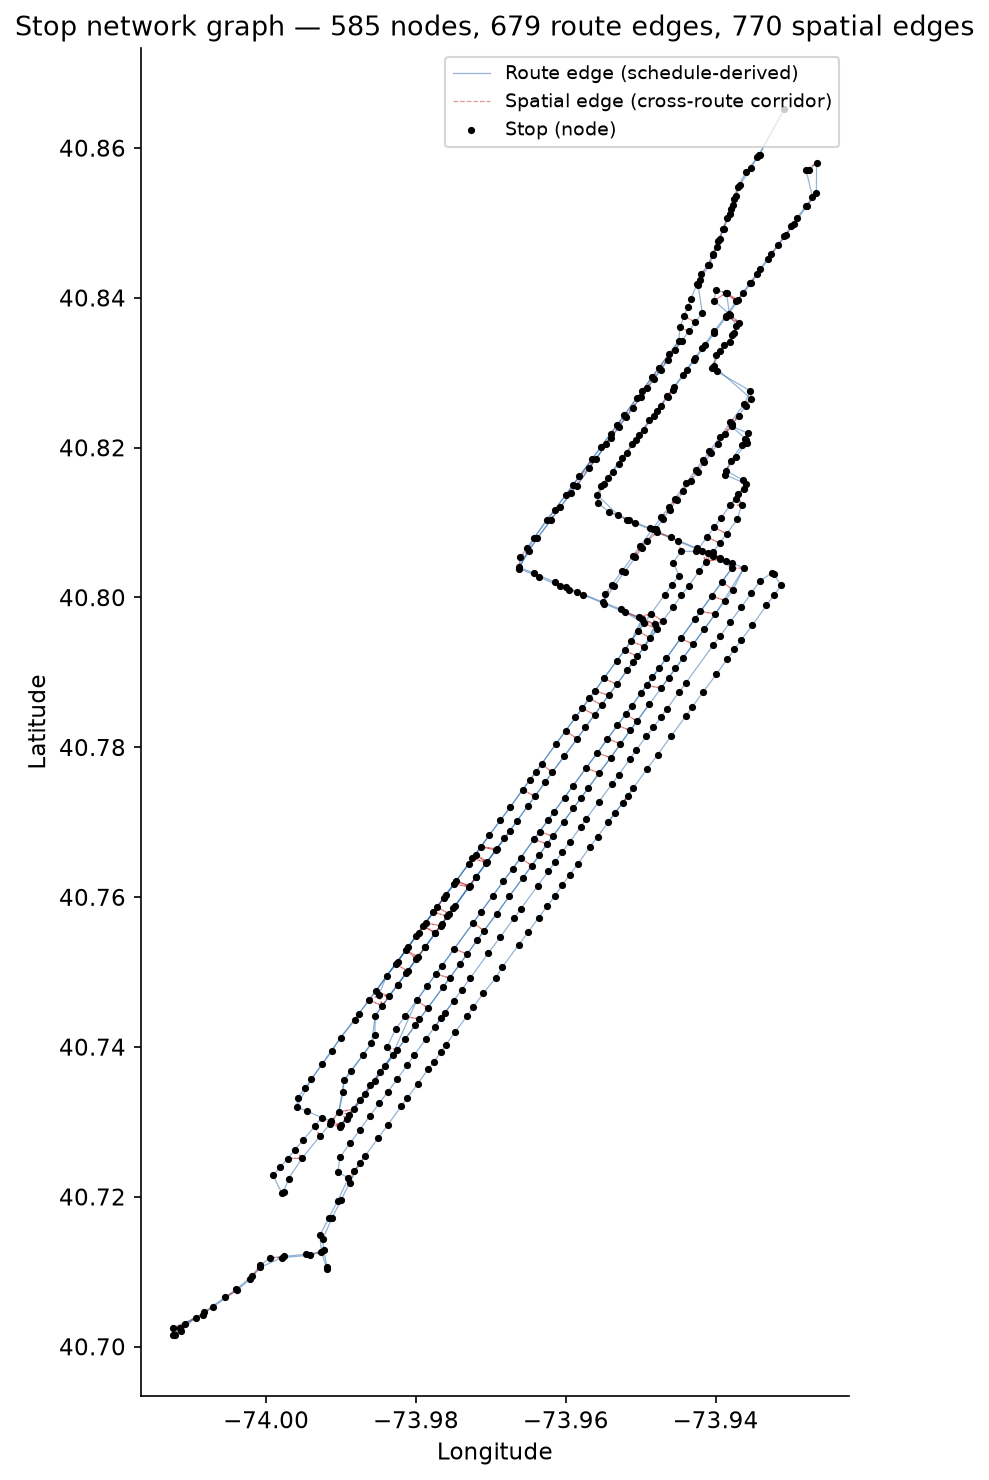

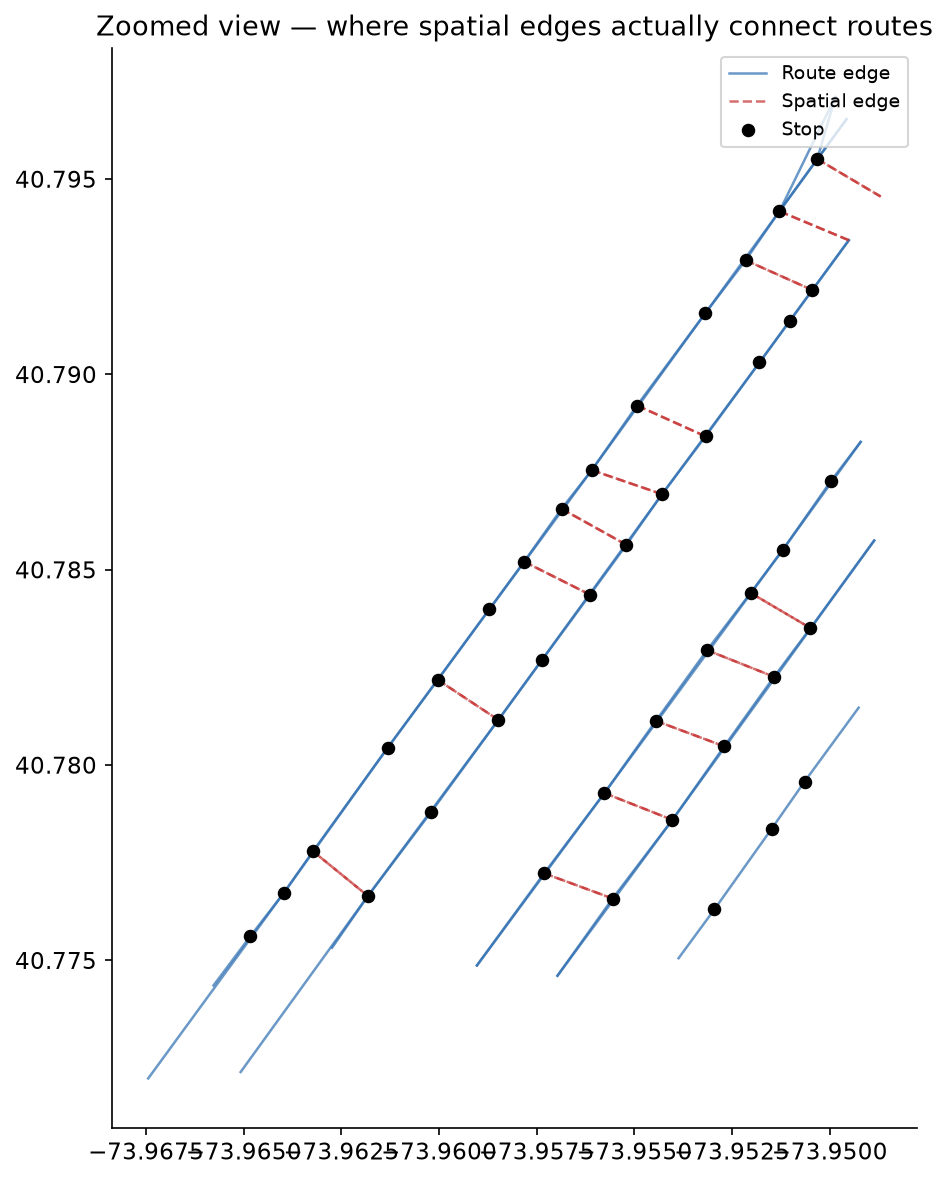

In [1]:
"""
Figure 1 — the network graph itself.

Draws every stop as a point, route edges as thin blue lines, and the
spatial (cross-route) edges as dashed red lines. This is the single
plot that visually justifies the whole GNN argument: it shows, in one
image, that stops from different routes sit close enough together to
warrant an edge the GTFS schedule alone would never give you.

Requires: processed/graph_nodes.parquet, processed/graph_edges.parquet
(from 01_build_graph.py).
"""
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

PROCESSED = Path("processed")
FIG_OUT = Path("figures")
FIG_OUT.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

nodes = pl.read_parquet(PROCESSED / "graph_nodes.parquet")
edges = pl.read_parquet(PROCESSED / "graph_edges.parquet")

lat = nodes["stop_lat"].to_numpy()
lon = nodes["stop_lon"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 10))

for edge_type, color, style, label, z in [
    ("route", "#2b6cb0", "-", "Route edge (schedule-derived)", 2),
    ("spatial", "#c53030", "--", "Spatial edge (cross-route corridor)", 3),
]:
    sub = edges.filter(pl.col("edge_type") == edge_type)
    src = sub["src_idx"].to_numpy()
    dst = sub["dst_idx"].to_numpy()
    first = True
    for s, d in zip(src, dst):
        ax.plot(
            [lon[s], lon[d]], [lat[s], lat[d]],
            color=color, linestyle=style, linewidth=0.6, alpha=0.5,
            zorder=z, label=label if first else None,
        )
        first = False

ax.scatter(lon, lat, s=6, color="black", zorder=4, label="Stop (node)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Stop network graph — {nodes.height} nodes, "
             f"{edges.filter(pl.col('edge_type')=='route').height} route edges, "
             f"{edges.filter(pl.col('edge_type')=='spatial').height} spatial edges")
ax.legend(loc="upper right", frameon=True, fontsize=9)
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(FIG_OUT / "01_network_graph.png")
print(f"saved {FIG_OUT / '01_network_graph.png'}")

# ---------------------------------------------------------------------
# Optional zoomed inset — pick the densest corner of the network so the
# spatial edges are actually visible at presentation resolution (they
# get lost in a full-network view of a big system).
# ---------------------------------------------------------------------
lon_mid, lat_mid = lon.mean(), lat.mean()
zoom_deg = 0.01  # ~1km box; shrink/grow to taste
fig2, ax2 = plt.subplots(figsize=(8, 8))
mask = (
    (lon > lon_mid - zoom_deg) & (lon < lon_mid + zoom_deg) &
    (lat > lat_mid - zoom_deg) & (lat < lat_mid + zoom_deg)
)
zoom_node_idx = set(nodes.filter(pl.Series(mask))["node_idx"].to_list())

for edge_type, color, style, label, z in [
    ("route", "#2b6cb0", "-", "Route edge", 2),
    ("spatial", "#c53030", "--", "Spatial edge", 3),
]:
    sub = edges.filter(pl.col("edge_type") == edge_type)
    src = sub["src_idx"].to_numpy()
    dst = sub["dst_idx"].to_numpy()
    first = True
    for s, d in zip(src, dst):
        if s in zoom_node_idx or d in zoom_node_idx:
            ax2.plot(
                [lon[s], lon[d]], [lat[s], lat[d]],
                color=color, linestyle=style, linewidth=1.2, alpha=0.7,
                zorder=z, label=label if first else None,
            )
            first = False

ax2.scatter(lon[mask], lat[mask], s=30, color="black", zorder=4, label="Stop")
ax2.set_title("Zoomed view — where spatial edges actually connect routes")
ax2.legend(loc="upper right", fontsize=9)
ax2.set_aspect("equal")
fig2.tight_layout()
fig2.savefig(FIG_OUT / "01b_network_graph_zoom.png")
print(f"saved {FIG_OUT / '01b_network_graph_zoom.png'}")
print("(adjust zoom_deg / recenter lon_mid,lat_mid if this box lands somewhere sparse)")

saved figures\02_temporal_patterns.png


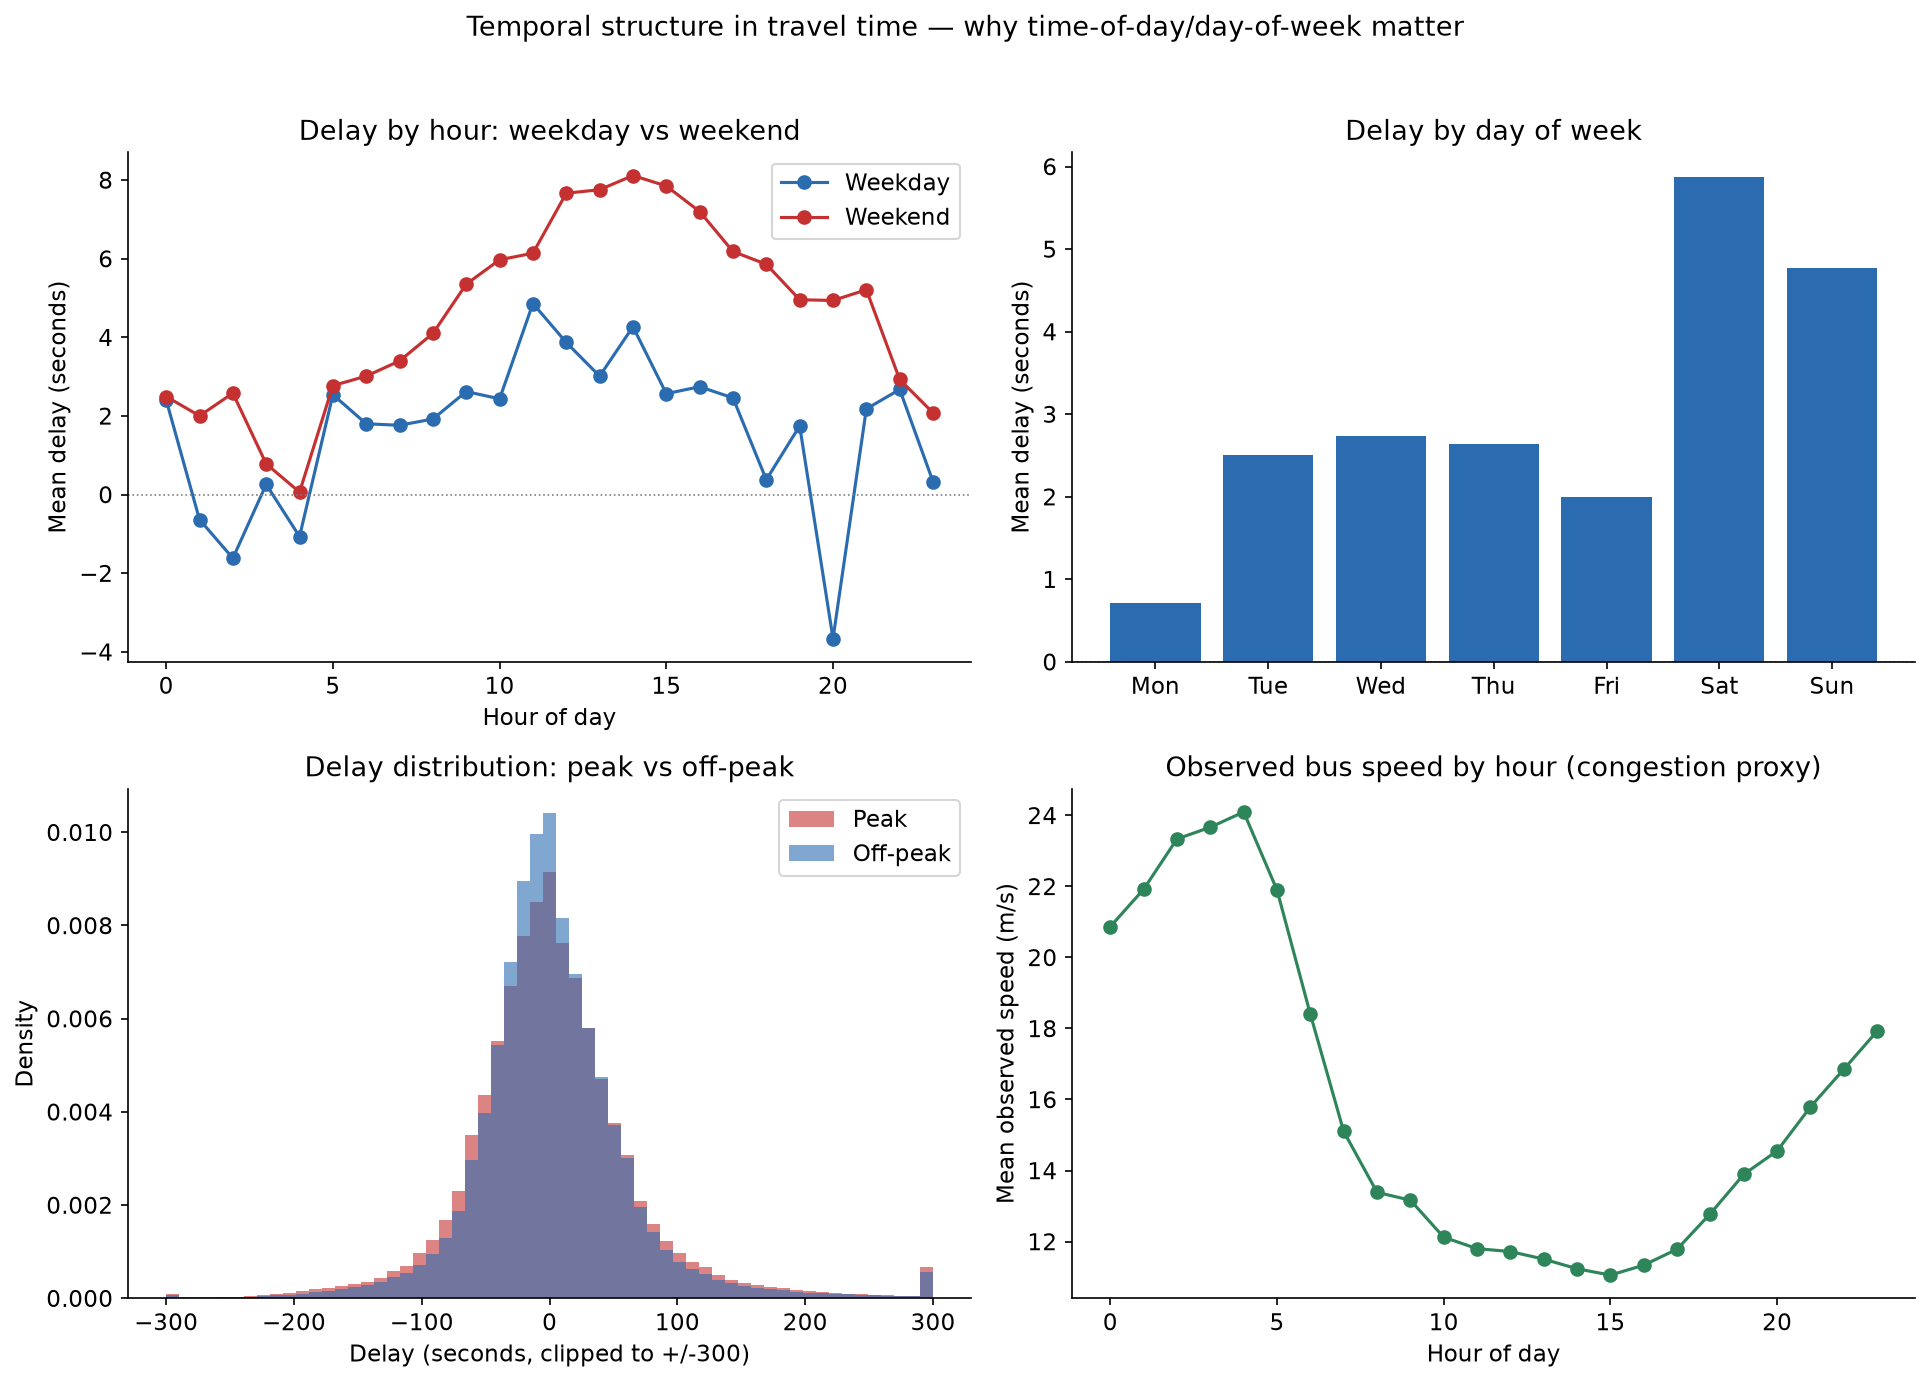

In [2]:
"""
Figure 2 — temporal patterns that motivate the temporal half of the
model (why a plain per-trip average isn't enough, and why hour/weekday/
peak features matter).

Requires: raw/processed_gtfs/baseline_dataset.parquet
(from build_dataset_chunked.ipynb).
"""
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

GTFS = Path("raw/processed_gtfs")
FIG_OUT = Path("figures")
FIG_OUT.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

df = pl.read_parquet(GTFS / "baseline_dataset.parquet")
df = df.with_columns(
    (pl.col("travel_time") - pl.col("scheduled_segment_time")).alias("delay_seconds")
)

WEEKDAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- (0,0) mean delay by hour, weekday vs weekend ---
by_hour = (
    df.group_by(["hour", "is_weekend"])
    .agg(pl.col("delay_seconds").mean().alias("mean_delay"))
    .sort("hour")
)
for is_weekend, color, label in [(0, "#2b6cb0", "Weekday"), (1, "#c53030", "Weekend")]:
    sub = by_hour.filter(pl.col("is_weekend") == is_weekend).sort("hour")
    axes[0, 0].plot(sub["hour"], sub["mean_delay"], marker="o", color=color, label=label)
axes[0, 0].axhline(0, color="gray", linewidth=0.8, linestyle=":")
axes[0, 0].set_xlabel("Hour of day")
axes[0, 0].set_ylabel("Mean delay (seconds)")
axes[0, 0].set_title("Delay by hour: weekday vs weekend")
axes[0, 0].legend()

# --- (0,1) mean delay by weekday ---
by_weekday = (
    df.group_by("weekday")
    .agg(pl.col("delay_seconds").mean().alias("mean_delay"))
    .sort("weekday")
)
wd = by_weekday["weekday"].to_numpy()
axes[0, 1].bar(
    [WEEKDAY_NAMES[w - 1] if 1 <= w <= 7 else str(w) for w in wd],
    by_weekday["mean_delay"], color="#2b6cb0",
)
axes[0, 1].axhline(0, color="gray", linewidth=0.8, linestyle=":")
axes[0, 1].set_ylabel("Mean delay (seconds)")
axes[0, 1].set_title("Delay by day of week")

# --- (1,0) delay distribution, peak vs off-peak ---
peak = df.filter(pl.col("is_peak") == 1)["delay_seconds"].to_numpy()
offpeak = df.filter(pl.col("is_peak") == 0)["delay_seconds"].to_numpy()
clip = 300  # +/- 5 min, for a readable x-axis; outliers still exist beyond this
bins = np.linspace(-clip, clip, 60)
axes[1, 0].hist(np.clip(peak, -clip, clip), bins=bins, alpha=0.6, label="Peak", color="#c53030", density=True)
axes[1, 0].hist(np.clip(offpeak, -clip, clip), bins=bins, alpha=0.6, label="Off-peak", color="#2b6cb0", density=True)
axes[1, 0].set_xlabel("Delay (seconds, clipped to +/-300)")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("Delay distribution: peak vs off-peak")
axes[1, 0].legend()

# --- (1,1) mean speed by hour, as a proxy for congestion ---
by_hour_speed = (
    df.group_by("hour")
    .agg(pl.col("speed_mps").mean().alias("mean_speed"))
    .sort("hour")
)
axes[1, 1].plot(by_hour_speed["hour"], by_hour_speed["mean_speed"], marker="o", color="#2f855a")
axes[1, 1].set_xlabel("Hour of day")
axes[1, 1].set_ylabel("Mean observed speed (m/s)")
axes[1, 1].set_title("Observed bus speed by hour (congestion proxy)")

fig.suptitle("Temporal structure in travel time — why time-of-day/day-of-week matter", y=1.02)
fig.tight_layout()
fig.savefig(FIG_OUT / "02_temporal_patterns.png", bbox_inches="tight")
print(f"saved {FIG_OUT / '02_temporal_patterns.png'}")

delay matrix: (2589, 585) (time_bins, nodes), 19.9% missing
spatial: n=652, mean corr=0.041
route: n=639, mean corr=0.076
random: n=2629, mean corr=0.012
saved figures\03_spatial_correlation.png


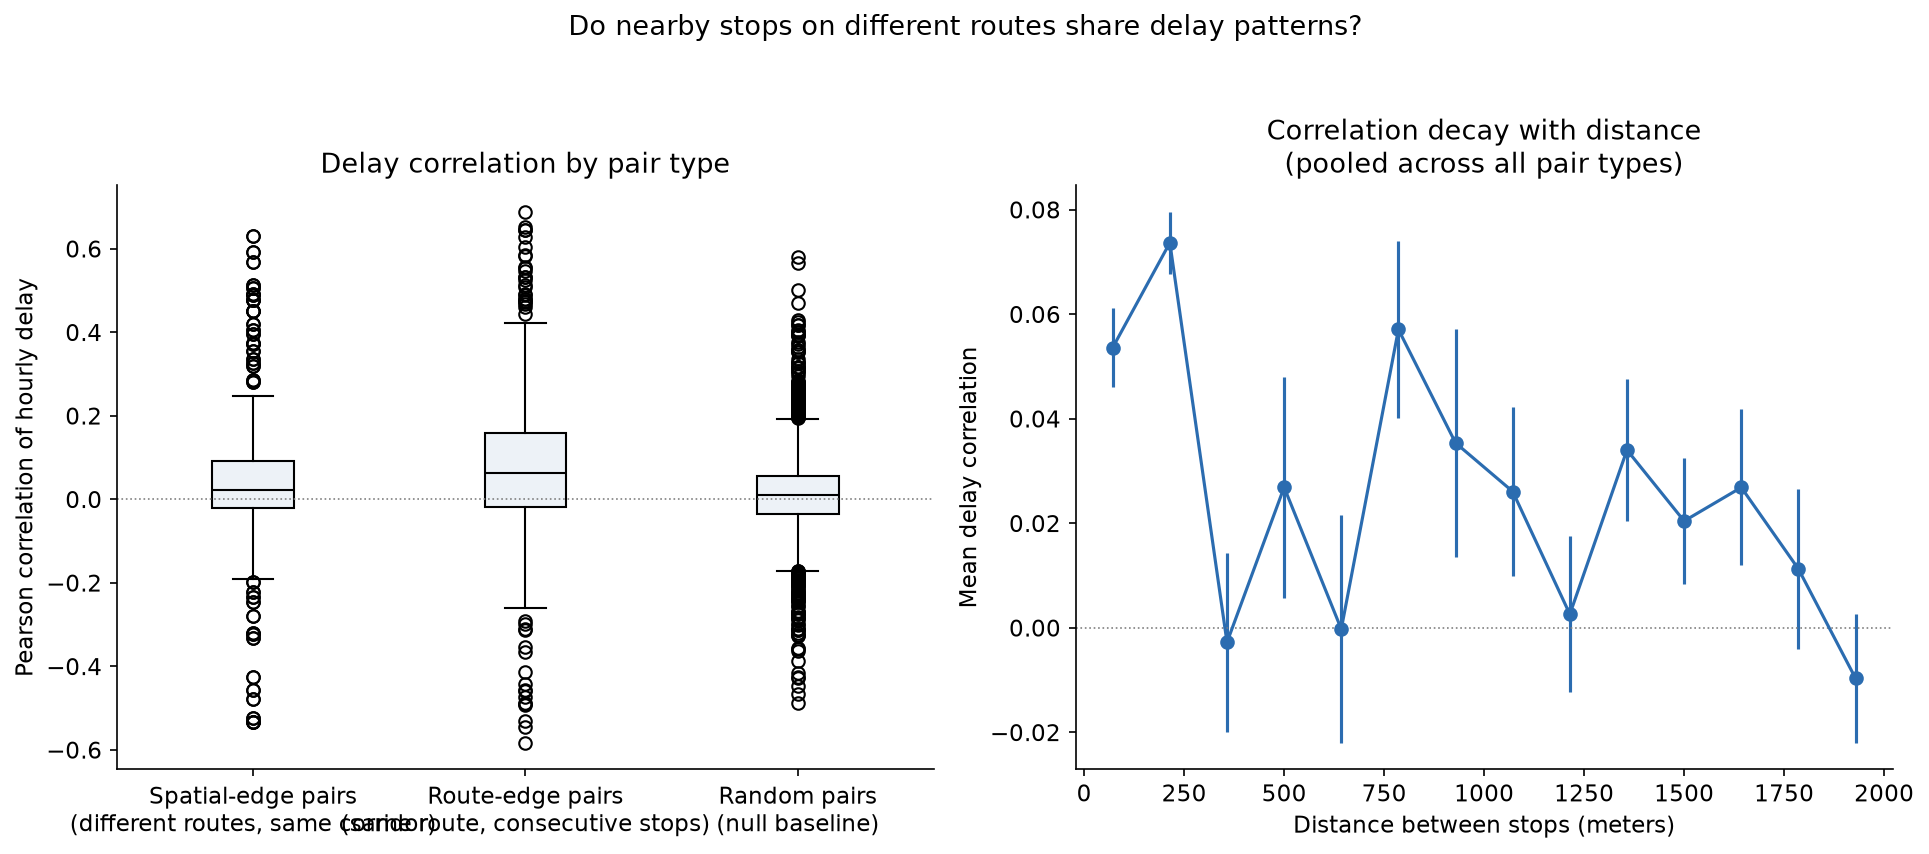

In [7]:
"""
Figure 3 — the evidence slide for the whole project: do stops that are
physically close (but on different routes/shapes, i.e. connected only by
a *spatial* edge) actually show correlated delay? If they don't, the
core GNN argument doesn't hold for this network and it's worth knowing
that before spending time training one.

Compares delay-correlation distributions for three pair categories:
  - spatial-edge pairs   (the new edges this project adds)
  - route-edge pairs     (already implicit in a per-trip sequence model)
  - random pairs         (baseline / null comparison)

and a correlation-vs-distance decay curve across all three pooled.

Requires: processed/graph_nodes.parquet, processed/graph_edges.parquet,
raw/processed_gtfs/baseline_dataset.parquet.
"""
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

GTFS = Path("raw/processed_gtfs")
PROCESSED = Path("processed")
FIG_OUT = Path("figures")
FIG_OUT.mkdir(exist_ok=True)

MAX_PAIRS_PER_CATEGORY = 3000
MIN_OVERLAP_BINS = 20   # require at least this many shared (date, hour) bins
RNG = np.random.default_rng(0)

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 200, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
})

nodes = pl.read_parquet(PROCESSED / "graph_nodes.parquet")
edges = pl.read_parquet(PROCESSED / "graph_edges.parquet")
n_nodes = nodes.height
stop_to_idx = dict(zip(nodes["stop_id"].to_list(), nodes["node_idx"].to_list()))
lat = nodes["stop_lat"].to_numpy()
lon = nodes["stop_lon"].to_numpy()

# ---------------------------------------------------------------------
# 1. Build a dense (n_time_bins, n_nodes) hourly mean-delay matrix.
#    Hourly (not 5-min) is plenty of resolution for this diagnostic and
#    keeps this a standalone script independent of the full STGCN
#    tensor pipeline.
# ---------------------------------------------------------------------
df = pl.read_parquet(GTFS / "baseline_dataset.parquet")
df = df.with_columns(
    pl.col("stop_id").cast(pl.Int64),
    (pl.col("travel_time") - pl.col("scheduled_segment_time")).alias("delay_seconds"),
)

df = df.with_columns(
    pl.col("stop_id")
      .replace_strict(stop_to_idx)
      .cast(pl.UInt32)
      .alias("node_idx")
)
agg = (
    df.group_by(["node_idx", "start_date", "hour"])
    .agg(pl.col("delay_seconds").mean().alias("delay"))
)
time_keys = (
    agg.select(["start_date", "hour"]).unique().sort(["start_date", "hour"])
    .with_row_index("time_idx")
)
agg = agg.join(time_keys, on=["start_date", "hour"], how="left")

n_time = time_keys.height
M = np.full((n_time, n_nodes), np.nan, dtype=np.float32)
M[agg["time_idx"].to_numpy(), agg["node_idx"].to_numpy()] = agg["delay"].to_numpy()
print(f"delay matrix: {M.shape} (time_bins, nodes), "
      f"{100 * np.isnan(M).mean():.1f}% missing")


def pairwise_corr(i: int, j: int) -> float | None:
    xi, xj = M[:, i], M[:, j]
    valid = ~np.isnan(xi) & ~np.isnan(xj)
    if valid.sum() < MIN_OVERLAP_BINS:
        return None
    if np.std(xi[valid]) == 0 or np.std(xj[valid]) == 0:
        return None
    return float(np.corrcoef(xi[valid], xj[valid])[0, 1])


def sample_pairs(pair_list, k):
    if len(pair_list) <= k:
        return pair_list
    idx = RNG.choice(len(pair_list), size=k, replace=False)
    return [pair_list[i] for i in idx]


spatial_pairs = list(zip(
    edges.filter(pl.col("edge_type") == "spatial")["src_idx"].to_list(),
    edges.filter(pl.col("edge_type") == "spatial")["dst_idx"].to_list(),
))
route_pairs = list(zip(
    edges.filter(pl.col("edge_type") == "route")["src_idx"].to_list(),
    edges.filter(pl.col("edge_type") == "route")["dst_idx"].to_list(),
))
spatial_pairs = sample_pairs(spatial_pairs, MAX_PAIRS_PER_CATEGORY)
route_pairs = sample_pairs(route_pairs, MAX_PAIRS_PER_CATEGORY)
random_pairs = [
    (int(a), int(b)) for a, b in
    RNG.integers(0, n_nodes, size=(MAX_PAIRS_PER_CATEGORY, 2))
    if a != b
]

results = {}
distances = {}
for name, pairs in [("spatial", spatial_pairs), ("route", route_pairs), ("random", random_pairs)]:
    corrs, dists = [], []
    for i, j in pairs:
        c = pairwise_corr(i, j)
        if c is None:
            continue
        corrs.append(c)
        R = 6371000.0
        lat0 = math.radians((lat[i] + lat[j]) / 2)
        dx = math.radians(lon[i] - lon[j]) * R * math.cos(lat0)
        dy = math.radians(lat[i] - lat[j]) * R
        dists.append(math.hypot(dx, dy))
    results[name] = np.array(corrs)
    distances[name] = np.array(dists)
    print(f"{name}: n={len(corrs)}, mean corr={np.mean(corrs):.3f}")

# ---------------------------------------------------------------------
# 2. Plot
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

colors = {"spatial": "#c53030", "route": "#2b6cb0", "random": "#718096"}
labels = {"spatial": "Spatial-edge pairs\n(different routes, same corridor)",
          "route": "Route-edge pairs\n(same route, consecutive stops)",
          "random": "Random pairs\n(null baseline)"}
axes[0].boxplot(
    [results["spatial"], results["route"], results["random"]],
    tick_labels=[labels[k] for k in ["spatial", "route", "random"]],
    patch_artist=True,
    boxprops=dict(facecolor="#edf2f7"),
    medianprops=dict(color="black"),
)
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle=":")
axes[0].set_ylabel("Pearson correlation of hourly delay")
axes[0].set_title("Delay correlation by pair type")

all_d = np.concatenate([distances[k] for k in distances])
all_c = np.concatenate([results[k] for k in distances])
order = np.argsort(all_d)
all_d, all_c = all_d[order], all_c[order]
bin_edges = np.linspace(0, min(all_d.max(), 2000), 15)
bin_idx = np.digitize(all_d, bin_edges)
bin_centers, bin_means, bin_stds = [], [], []
for b in range(1, len(bin_edges)):
    sel = bin_idx == b
    if sel.sum() < 5:
        continue
    bin_centers.append((bin_edges[b - 1] + bin_edges[b]) / 2)
    bin_means.append(all_c[sel].mean())
    bin_stds.append(all_c[sel].std() / np.sqrt(sel.sum()))
axes[1].errorbar(bin_centers, bin_means, yerr=bin_stds, marker="o", color="#2b6cb0")
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle=":")
axes[1].set_xlabel("Distance between stops (meters)")
axes[1].set_ylabel("Mean delay correlation")
axes[1].set_title("Correlation decay with distance\n(pooled across all pair types)")

fig.suptitle("Do nearby stops on different routes share delay patterns?", y=1.03)
fig.tight_layout()
fig.savefig(FIG_OUT / "03_spatial_correlation.png", bbox_inches="tight")
print(f"saved {FIG_OUT / '03_spatial_correlation.png'}")

saved figures\04_data_overview.png


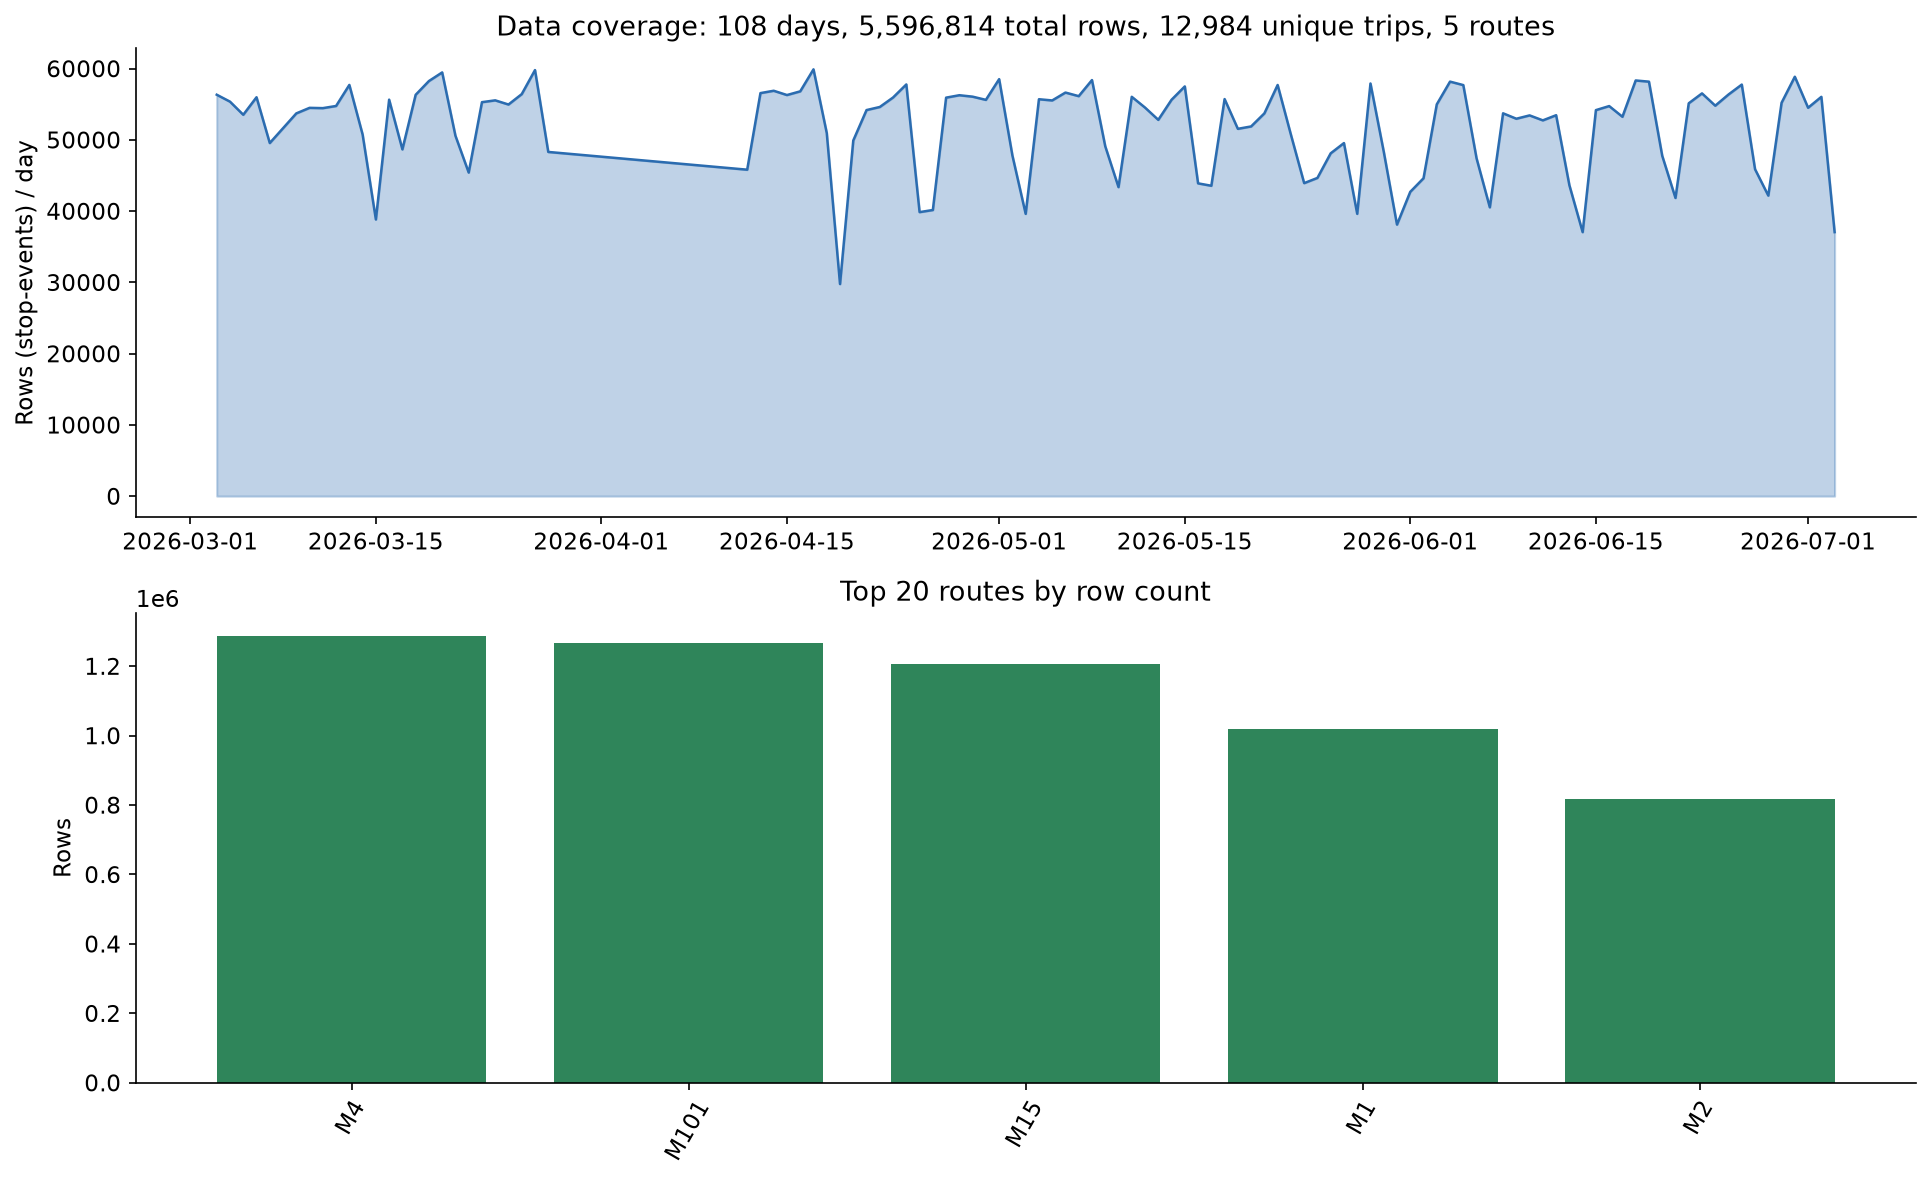

In [8]:
"""
Figure 4 — dataset scale/coverage summary, a good opening slide before
getting into modeling: how much data, over what period, how complete.

Requires: raw/processed_gtfs/baseline_dataset.parquet
"""
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

GTFS = Path("raw/processed_gtfs")
FIG_OUT = Path("figures")
FIG_OUT.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 200, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
})

df = pl.read_parquet(GTFS / "baseline_dataset.parquet")
df = df.with_columns(
    pl.col("start_date").str.strptime(pl.Date, "%Y%m%d").alias("service_date")
)

by_day = (
    df.group_by("service_date")
    .agg([pl.len().alias("n_rows"), pl.col("trip_id").n_unique().alias("n_trips")])
    .sort("service_date")
)
by_route = (
    df.group_by("route_id")
    .agg(pl.len().alias("n_rows"))
    .sort("n_rows", descending=True)
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].fill_between(by_day["service_date"], by_day["n_rows"], color="#2b6cb0", alpha=0.3)
axes[0].plot(by_day["service_date"], by_day["n_rows"], color="#2b6cb0", linewidth=1.2)
axes[0].set_ylabel("Rows (stop-events) / day")
axes[0].set_title(
    f"Data coverage: {by_day.height} days, "
    f"{df.height:,} total rows, {df['trip_id'].n_unique():,} unique trips, "
    f"{df['route_id'].n_unique()} routes"
)

top_n = 20
top_routes = by_route.head(top_n)
axes[1].bar(top_routes["route_id"].to_list(), top_routes["n_rows"], color="#2f855a")
axes[1].set_ylabel("Rows")
axes[1].set_title(f"Top {top_n} routes by row count")
axes[1].tick_params(axis="x", rotation=60)

fig.tight_layout()
fig.savefig(FIG_OUT / "04_data_overview.png", bbox_inches="tight")
print(f"saved {FIG_OUT / '04_data_overview.png'}")

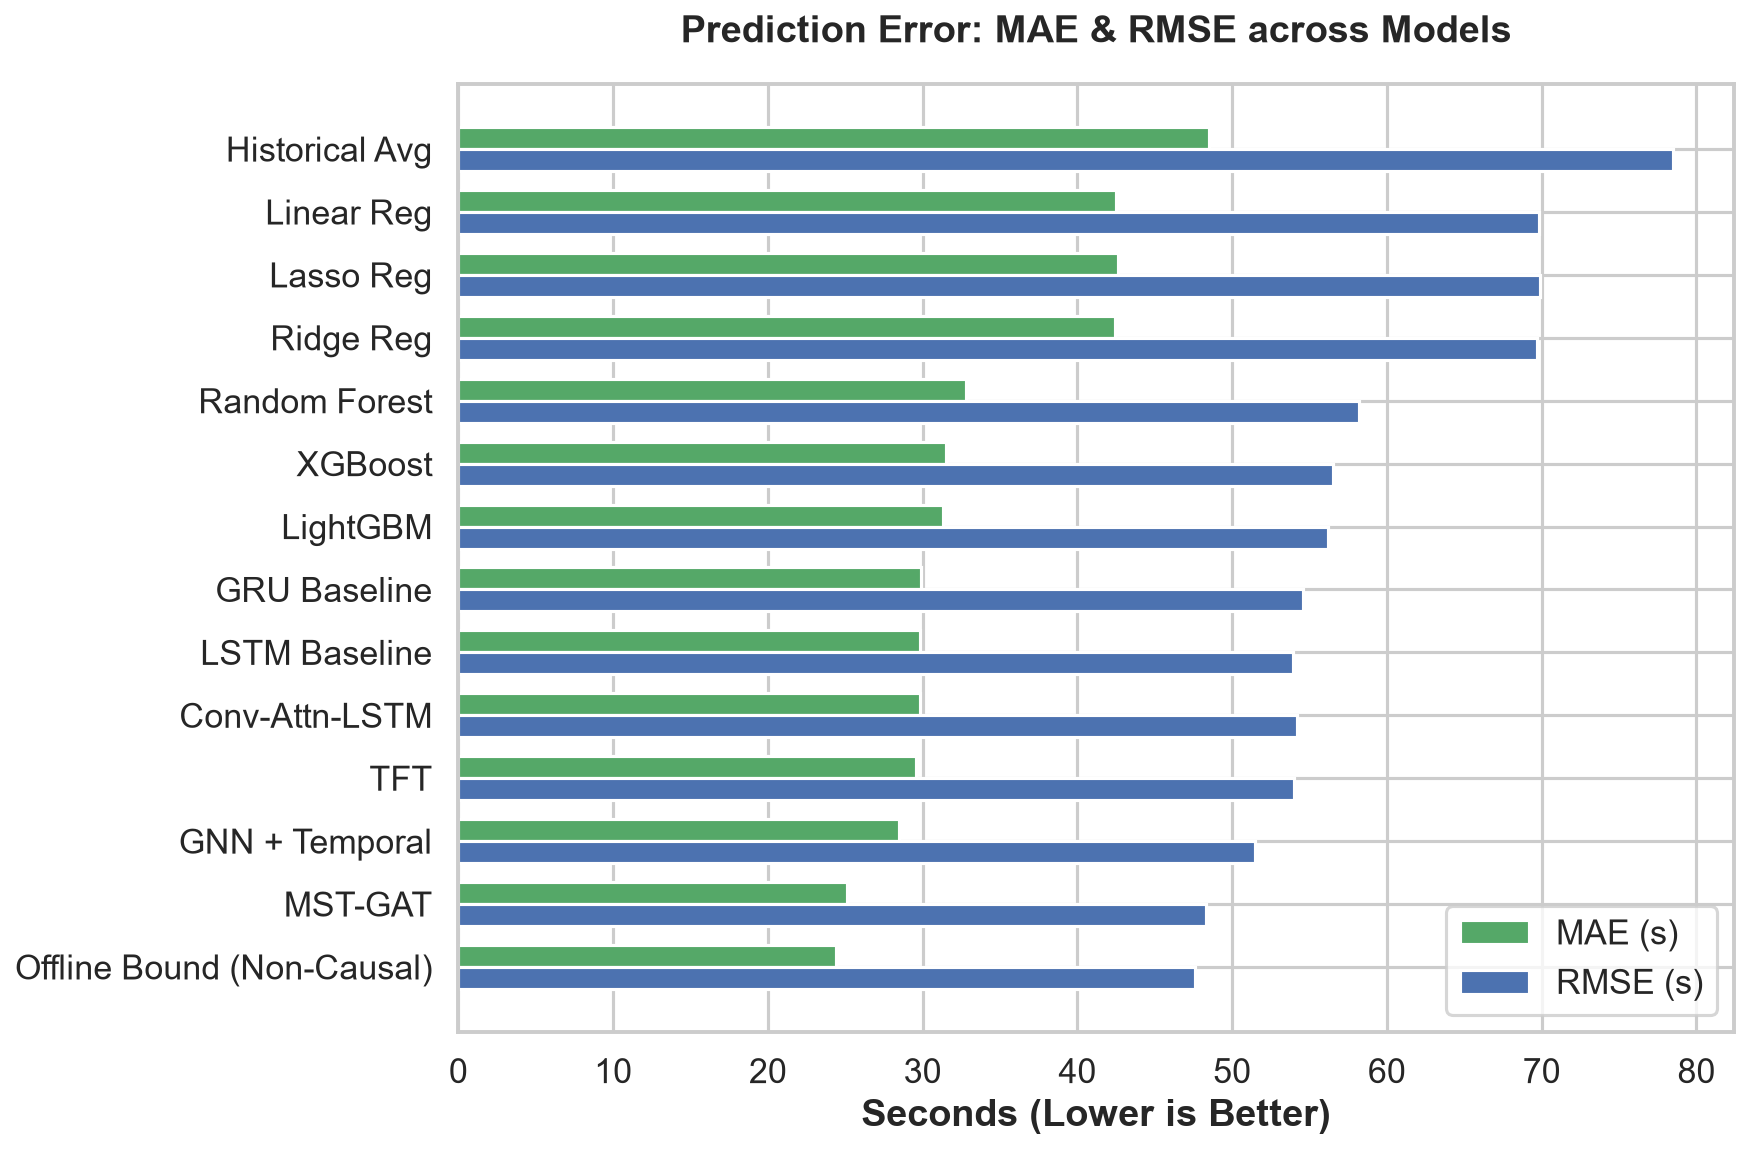

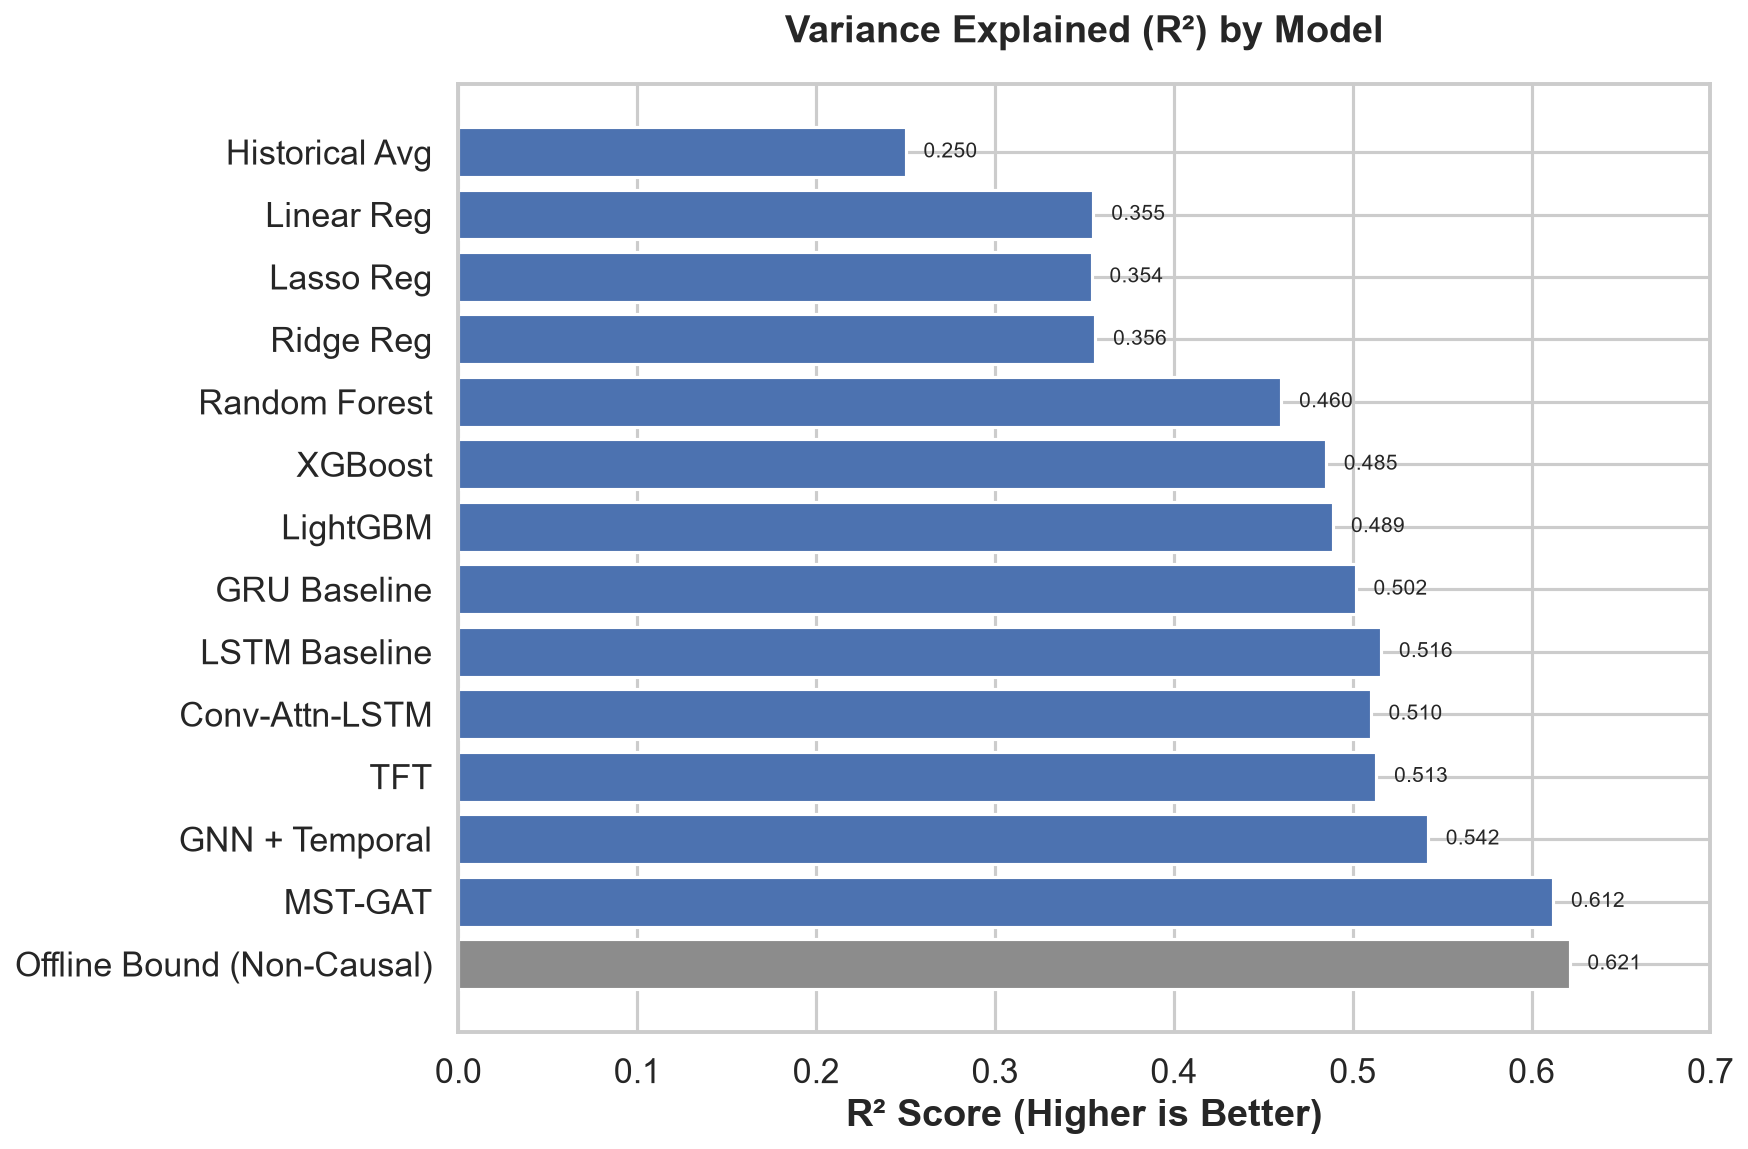

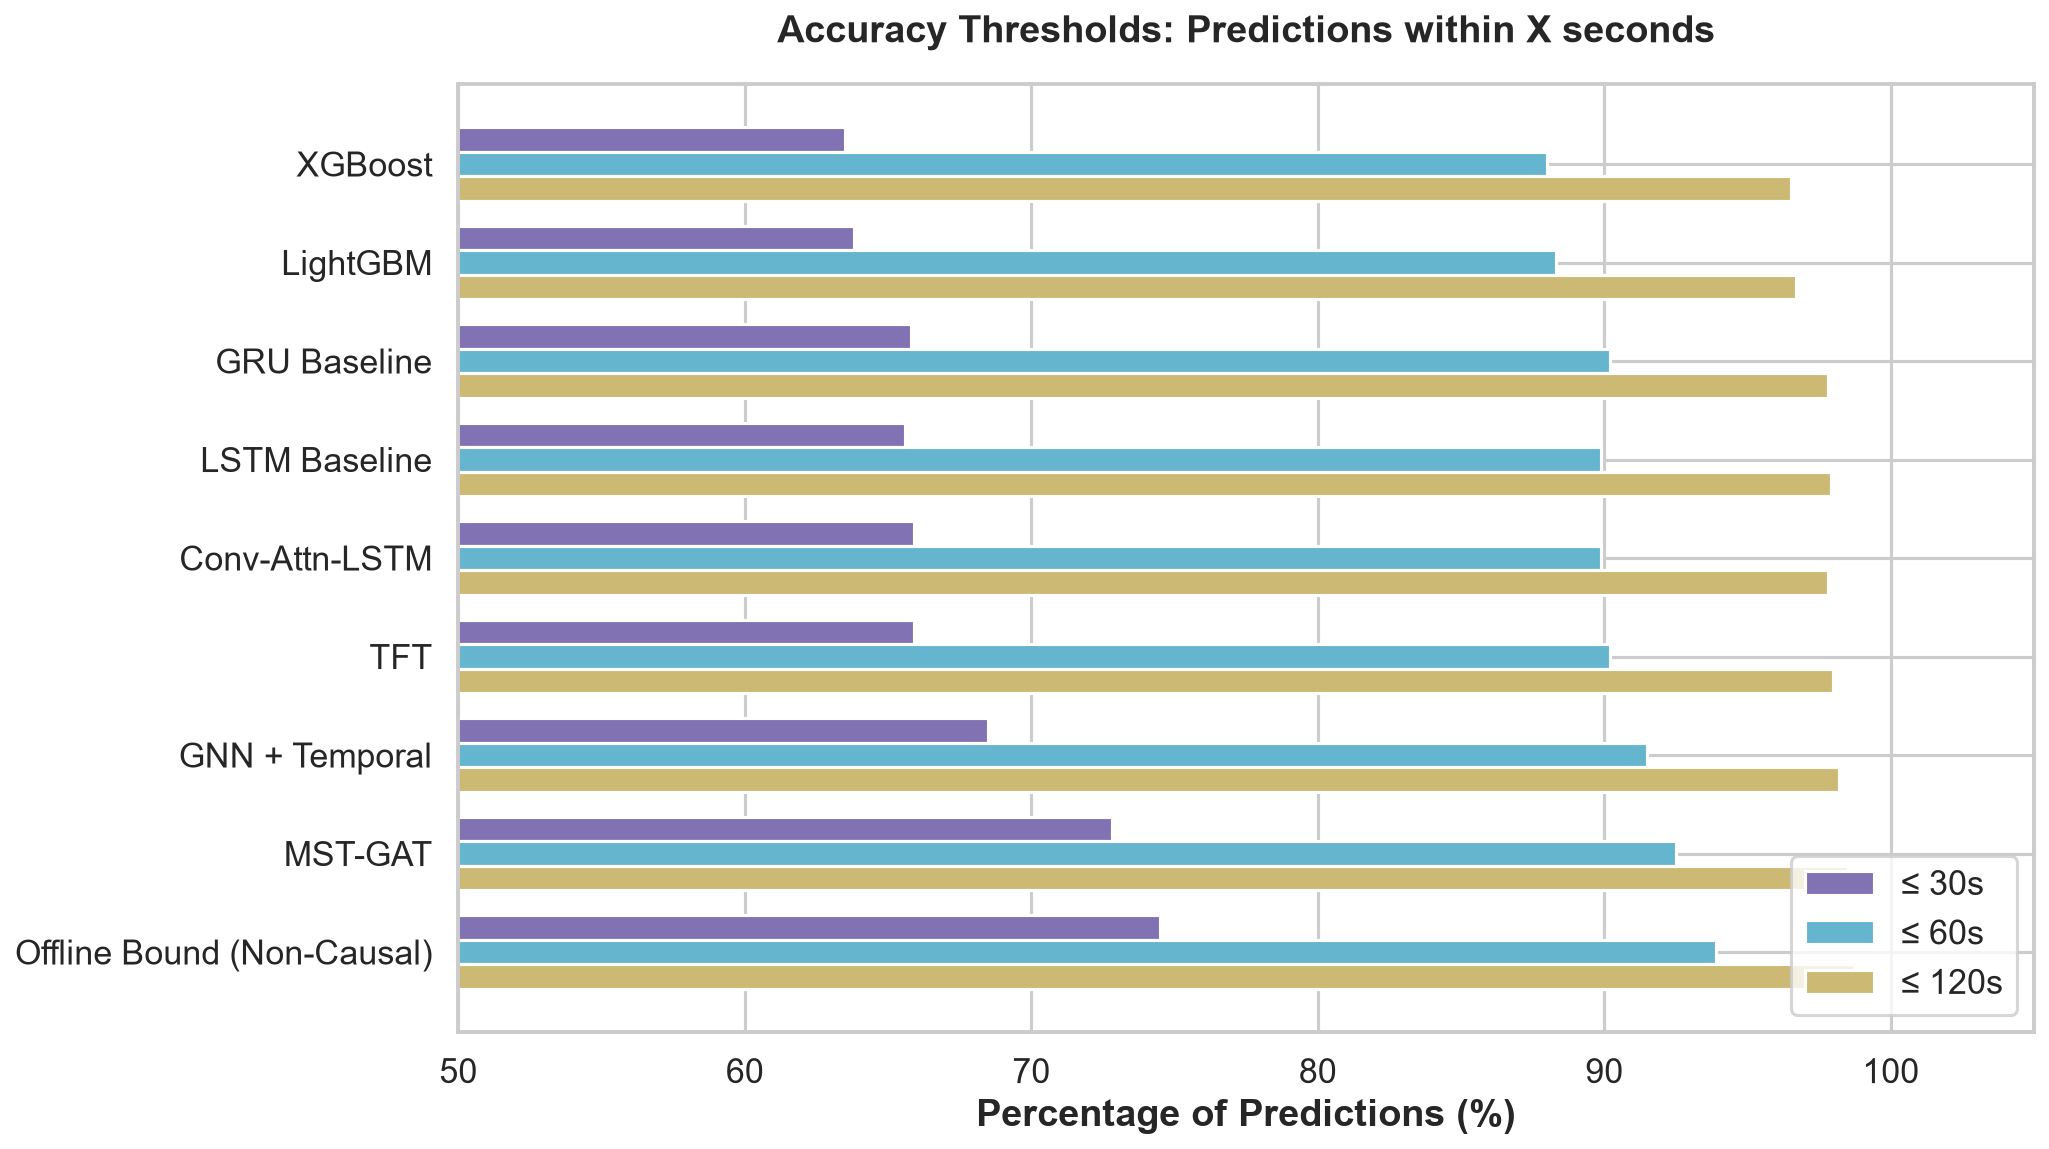

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare the Data (Now including LightGBM)
data = {
    "Model": [
        "Historical Avg", "Linear Reg", "Lasso Reg", "Ridge Reg", 
        "Random Forest", "XGBoost", "LightGBM", "GRU Baseline", "LSTM Baseline", 
        "Conv-Attn-LSTM", "TFT", "GNN + Temporal", "MST-GAT", 
        "Offline Bound (Non-Causal)"
    ],
    "MAE": [48.5, 42.5, 42.6, 42.4, 32.8, 31.5, 31.3, 29.9, 29.8, 29.8, 29.6, 28.5, 25.1, 24.4],
    "RMSE": [78.5, 69.8, 69.9, 69.7, 58.2, 56.5, 56.2, 54.6, 53.9, 54.2, 54.0, 51.5, 48.3, 47.6],
    "R2": [0.2500, 0.3550, 0.3540, 0.3560, 0.4600, 0.4850, 0.4890, 0.5016, 0.5158, 0.5100, 0.5131, 0.5420, 0.6120, 0.6212],
    "Within_30s": [42.0, 48.5, 48.4, 48.6, 61.2, 63.5, 63.8, 65.8, 65.6, 65.9, 65.9, 68.5, 72.8, 74.5],
    "Within_60s": [68.5, 75.2, 75.1, 75.3, 86.5, 88.0, 88.3, 90.2, 89.9, 89.9, 90.2, 91.5, 92.5, 93.9],
    "Within_120s": [86.5, 91.0, 90.9, 91.1, 95.8, 96.5, 96.7, 97.8, 97.9, 97.8, 98.0, 98.2, 98.5, 98.7]
}

df = pd.DataFrame(data)

# Set general presentation aesthetics
sns.set_theme(style="whitegrid", context="talk")
primary_color = "#4C72B0"  # Muted blue for baselines
highlight_color = "#C44E52" # Muted red to make the proposed model pop
bound_color = "#8C8C8C" # Grey for the offline upper bound

# Create a color palette based on model name
colors = []
for model in df["Model"]:
    if "Proposed" in model:
        colors.append(highlight_color)
    elif "Offline" in model:
        colors.append(bound_color)
    else:
        colors.append(primary_color)

# ==========================================
# Graph 1: MAE and RMSE (Lower is Better)
# ==========================================
fig, ax = plt.subplots(figsize=(12, 8))
y = np.arange(len(df["Model"]))
height = 0.35

ax.barh(y - height/2, df["MAE"], height, label='MAE (s)', color="#55A868")
ax.barh(y + height/2, df["RMSE"], height, label='RMSE (s)', color="#4C72B0")

ax.set_yticks(y)
ax.set_yticklabels(df["Model"])
ax.invert_yaxis()  # Put the best models at the bottom
ax.set_xlabel("Seconds (Lower is Better)", fontweight='bold')
ax.set_title("Prediction Error: MAE & RMSE across Models", fontweight='bold', pad=20)
ax.legend()

# Bold the proposed model label
for tick in ax.get_yticklabels():
    if "Proposed" in tick.get_text():
        tick.set_fontweight('bold')
        tick.set_color(highlight_color)

plt.tight_layout()
plt.show()

# ==========================================
# Graph 2: R-Squared (Higher is Better)
# ==========================================
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df["Model"], df["R2"], color=colors)
ax.invert_yaxis()

ax.set_xlabel("R² Score (Higher is Better)", fontweight='bold')
ax.set_title("Variance Explained (R²) by Model", fontweight='bold', pad=20)
ax.set_xlim(0, 0.7)

# Add value labels to the end of the bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{width:.3f}', va='center', ha='left', fontsize=10)

# Bold the proposed model label
for tick in ax.get_yticklabels():
    if "Proposed" in tick.get_text():
        tick.set_fontweight('bold')
        tick.set_color(highlight_color)

plt.tight_layout()
plt.show()

# ==========================================
# Graph 3: Accuracy Thresholds (Cumulative)
# ==========================================
# Filter out the weaker baselines to make the chart less cluttered for the audience
# Adjusted to tail(9) to ensure LightGBM is included in the visual
top_models = df.tail(9).copy()
y_top = np.arange(len(top_models["Model"]))
height_top = 0.25

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(y_top - height_top, top_models["Within_30s"], height_top, label='≤ 30s', color="#8172B3")
ax.barh(y_top, top_models["Within_60s"], height_top, label='≤ 60s', color="#64B5CD")
ax.barh(y_top + height_top, top_models["Within_120s"], height_top, label='≤ 120s', color="#CCB974")

ax.set_yticks(y_top)
ax.set_yticklabels(top_models["Model"])
ax.invert_yaxis()
ax.set_xlabel("Percentage of Predictions (%)", fontweight='bold')
ax.set_title("Accuracy Thresholds: Predictions within X seconds", fontweight='bold', pad=20)
ax.set_xlim(50, 105) # Start at 50% to emphasize the differences at the high end
ax.legend(loc='lower right')

# Bold the proposed model label
for tick in ax.get_yticklabels():
    if "Proposed" in tick.get_text():
        tick.set_fontweight('bold')
        tick.set_color(highlight_color)

plt.tight_layout()
plt.show()

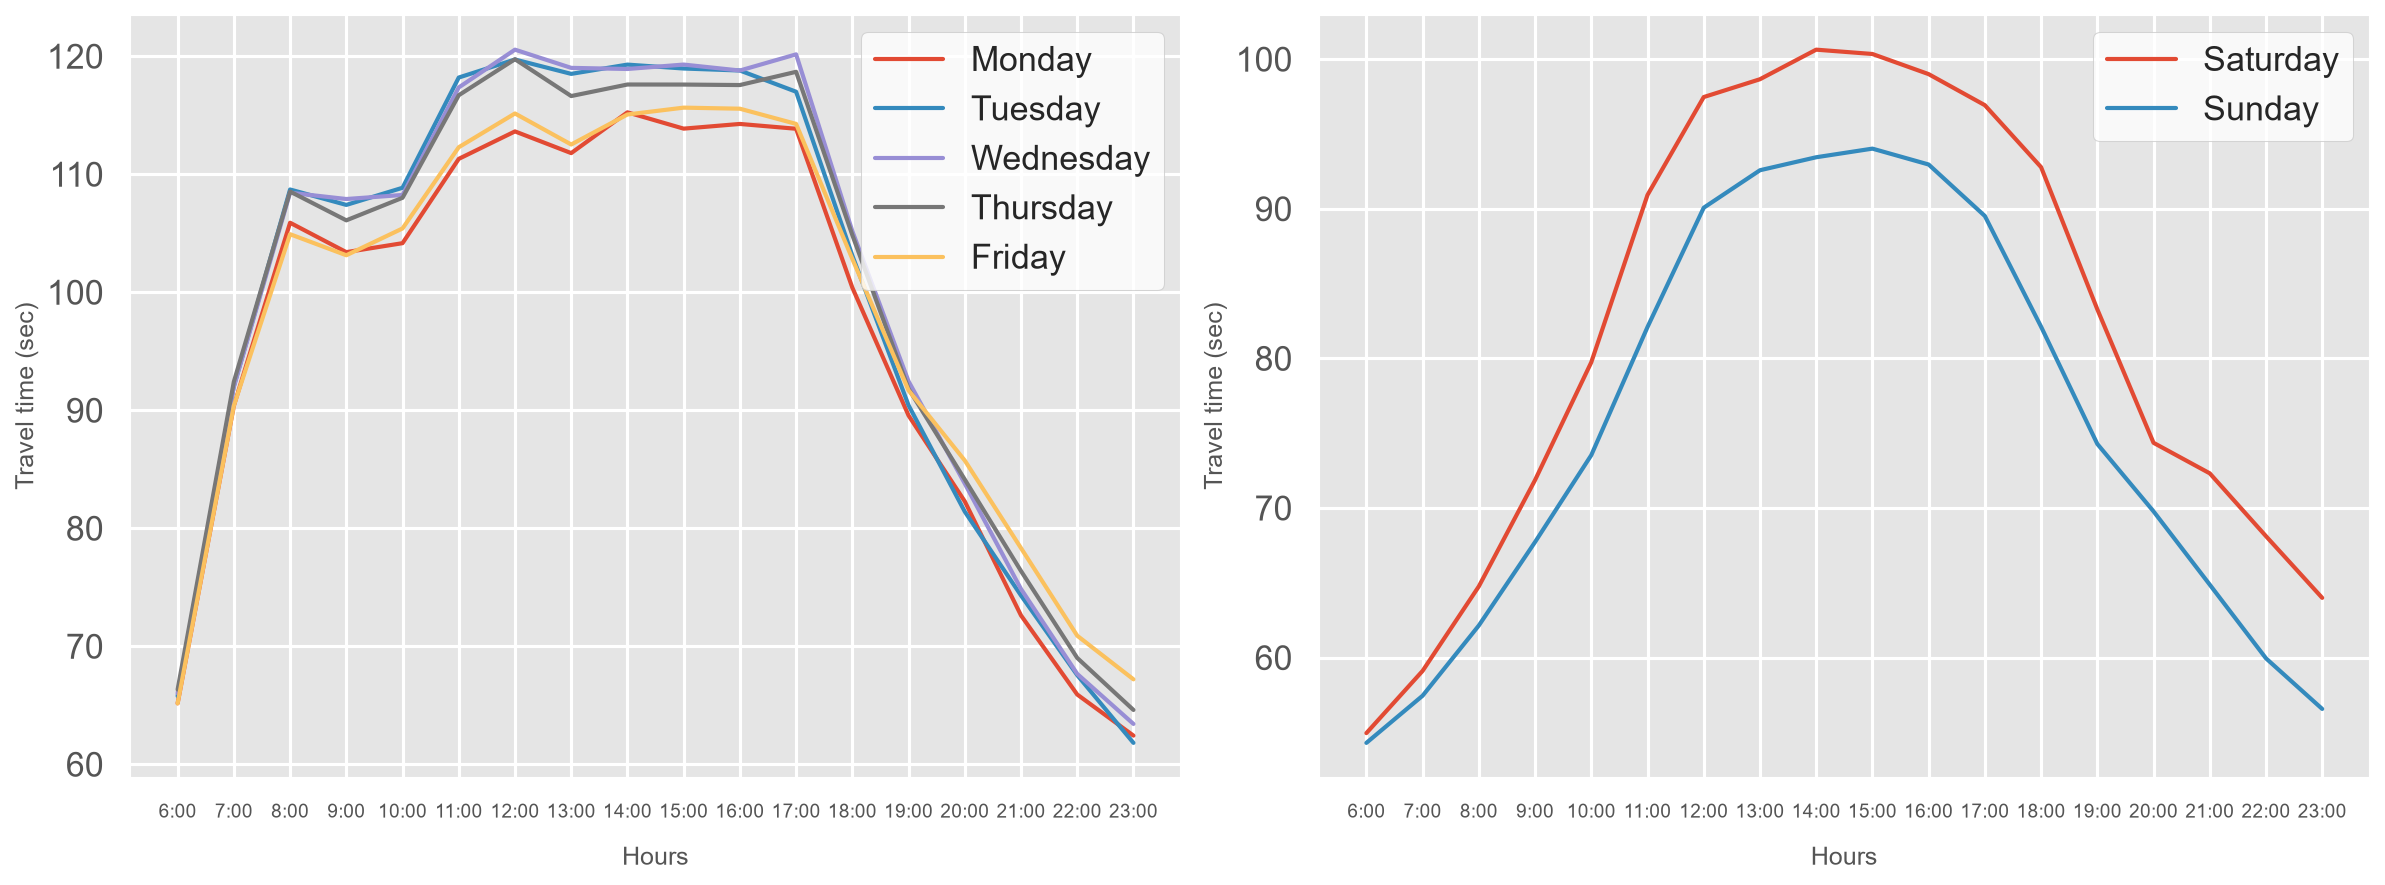

In [14]:
import polars as pl
import matplotlib.pyplot as plt

# Load dataset
d = pl.read_parquet("raw/processed_gtfs/baseline_dataset.parquet")

# Aggregate average travel time by weekday and hour
g = d.group_by(["weekday", "hour"]).agg(pl.col("travel_time").mean()).sort(["weekday", "hour"])

# Use ggplot style to mimic the gray background and white gridlines
plt.style.use('ggplot')
f, a = plt.subplots(1, 2, figsize=(16, 6))

w_m = {1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday", 5: "Friday"}
e_m = {6: "Saturday", 7: "Sunday"}

# Left plot: Weekdays
for w, n in w_m.items():
    w_d = g.filter((pl.col("weekday") == w) & (pl.col("hour") >= 6) & (pl.col("hour") <= 23))
    a[0].plot(w_d["hour"], w_d["travel_time"], label=n, linewidth=2)

# Right plot: Weekends
for w, n in e_m.items():
    e_d = g.filter((pl.col("weekday") == w) & (pl.col("hour") >= 6) & (pl.col("hour") <= 23))
    a[1].plot(e_d["hour"], e_d["travel_time"], label=n, linewidth=2)

t = list(range(6, 24))
l = [f"{h}:00" for h in t]

for i in range(2):
    a[i].set_xticks(t)
    a[i].set_xticklabels(l, fontsize=9)
    a[i].set_xlabel("Hours", labelpad=12)
    a[i].set_ylabel("Travel time (sec)")
    a[i].legend(loc="upper right", frameon=True, facecolor="white")

plt.tight_layout()
plt.show()

saved figures\travel_time_by_hour_weekday_weekend.png


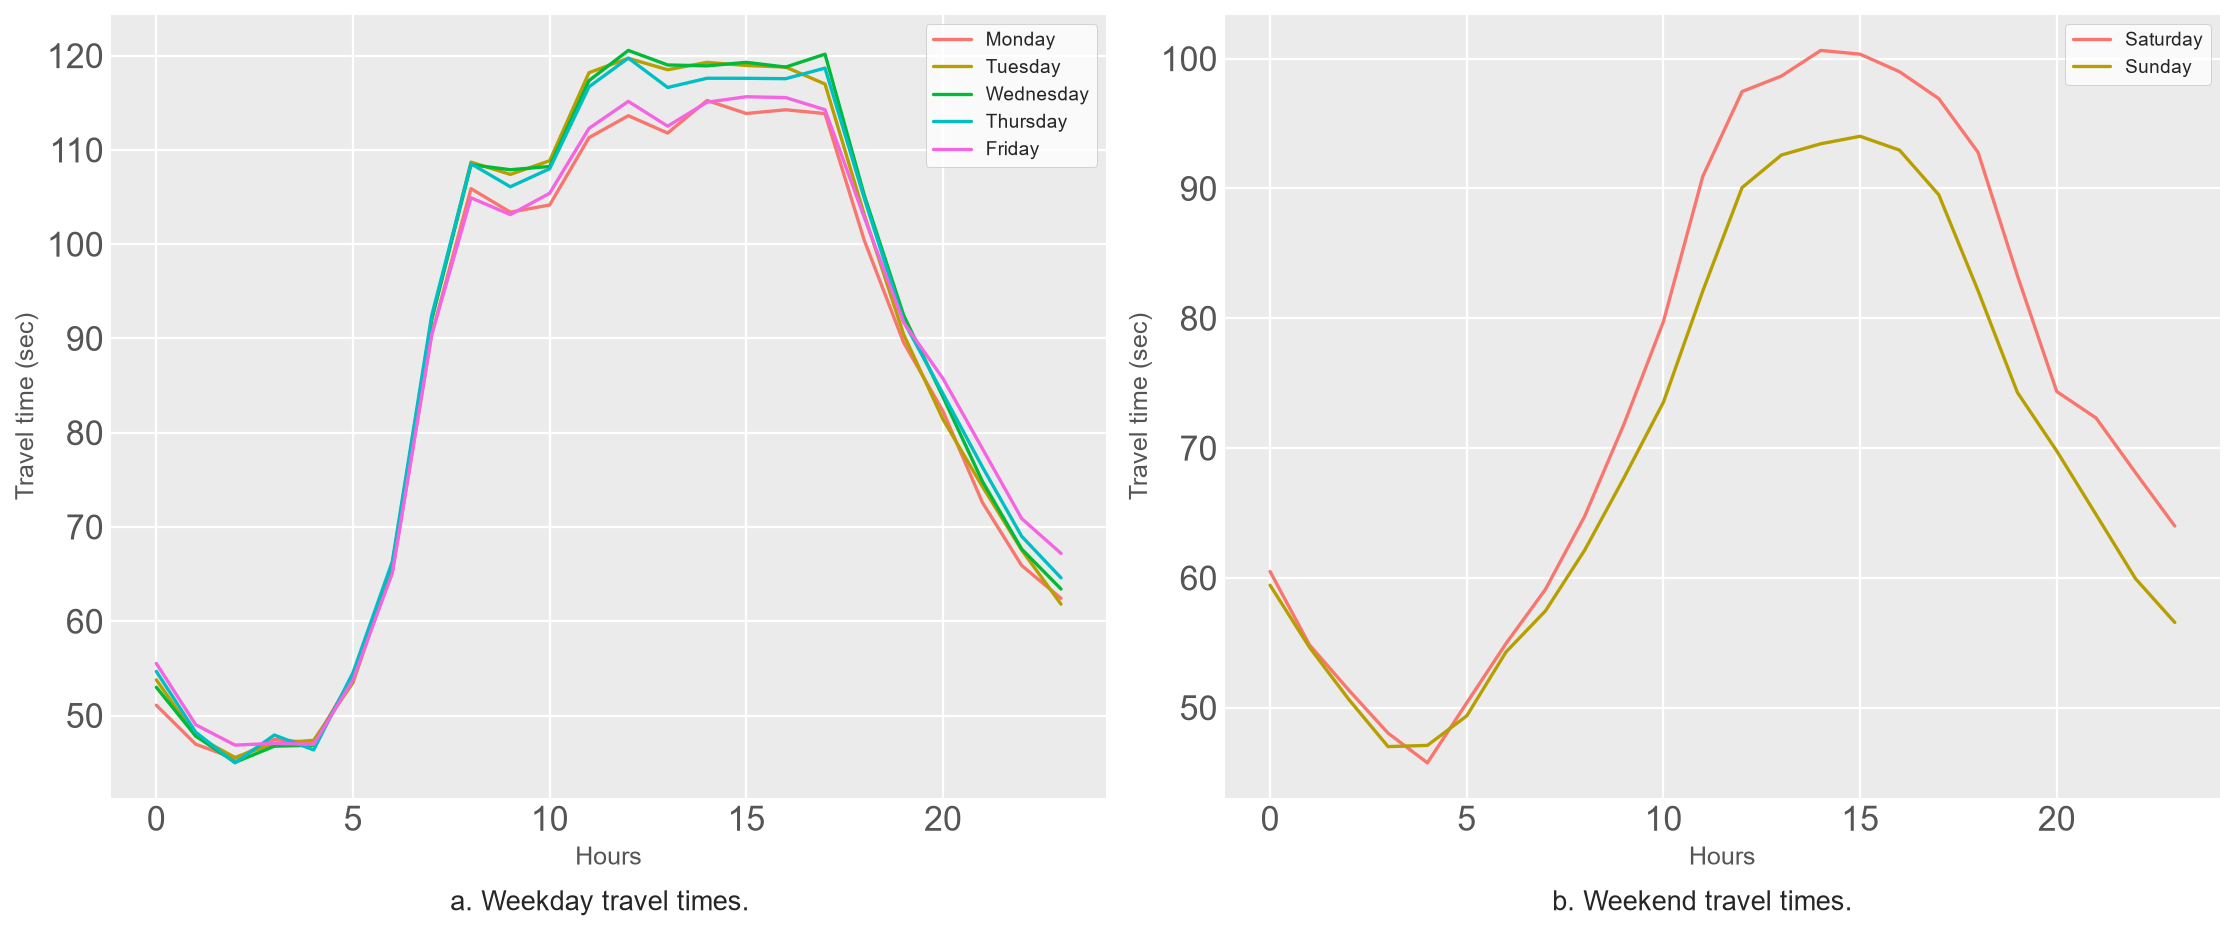

In [15]:
"""
Figure — mean travel time by hour, one line per day of week, split into
weekday panel (Mon-Fri) and weekend panel (Sat-Sun), styled to match a
ggplot2 default theme (gray panel background, white gridlines).

Requires: raw/processed_gtfs/baseline_dataset.parquet
"""
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

GTFS = Path("raw/processed_gtfs")
FIG_OUT = Path("figures")
FIG_OUT.mkdir(exist_ok=True)

# ggplot2-like palette (default hue order) and panel styling
DAY_COLORS = {
    "Monday": "#F8766D", "Tuesday": "#B79F00", "Wednesday": "#00BA38",
    "Thursday": "#00BFC4", "Friday": "#F564E3",
    "Saturday": "#F8766D", "Sunday": "#B79F00",
}
WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
WEEKEND_ORDER = ["Saturday", "Sunday"]
# weekday column convention: adjust if your `weekday` is 0=Sunday or 1=Monday etc.
WEEKDAY_NUM_TO_NAME = {
    1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday",
    5: "Friday", 6: "Saturday", 7: "Sunday",
}


def style_like_ggplot(ax):
    ax.set_facecolor("#EBEBEB")
    ax.grid(True, color="white", linewidth=1.1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)


df = pl.read_parquet(GTFS / "baseline_dataset.parquet")
df = df.with_columns(
    pl.col("weekday").replace_strict(WEEKDAY_NUM_TO_NAME).alias("day_name")
)

by_hour_day = (
    df.group_by(["day_name", "hour"])
    .agg(pl.col("travel_time").mean().alias("mean_travel_time"))
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, day_order, title in [
    (axes[0], WEEKDAY_ORDER, "a. Weekday travel times."),
    (axes[1], WEEKEND_ORDER, "b. Weekend travel times."),
]:
    for day in day_order:
        sub = by_hour_day.filter(pl.col("day_name") == day).sort("hour")
        if sub.height == 0:
            continue
        ax.plot(
            sub["hour"], sub["mean_travel_time"],
            color=DAY_COLORS[day], linewidth=1.6, label=day,
        )
    style_like_ggplot(ax)
    ax.set_xlabel("Hours")
    ax.set_ylabel("Travel time (sec)")
    ax.legend(frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=9)
    ax.set_title("")

fig.text(0.27, -0.02, "a. Weekday travel times.", ha="center", fontsize=13)
fig.text(0.76, -0.02, "b. Weekend travel times.", ha="center", fontsize=13)

fig.tight_layout()
fig.savefig(FIG_OUT / "travel_time_by_hour_weekday_weekend.png",
            bbox_inches="tight", dpi=200)
print(f"saved {FIG_OUT / 'travel_time_by_hour_weekday_weekend.png'}")

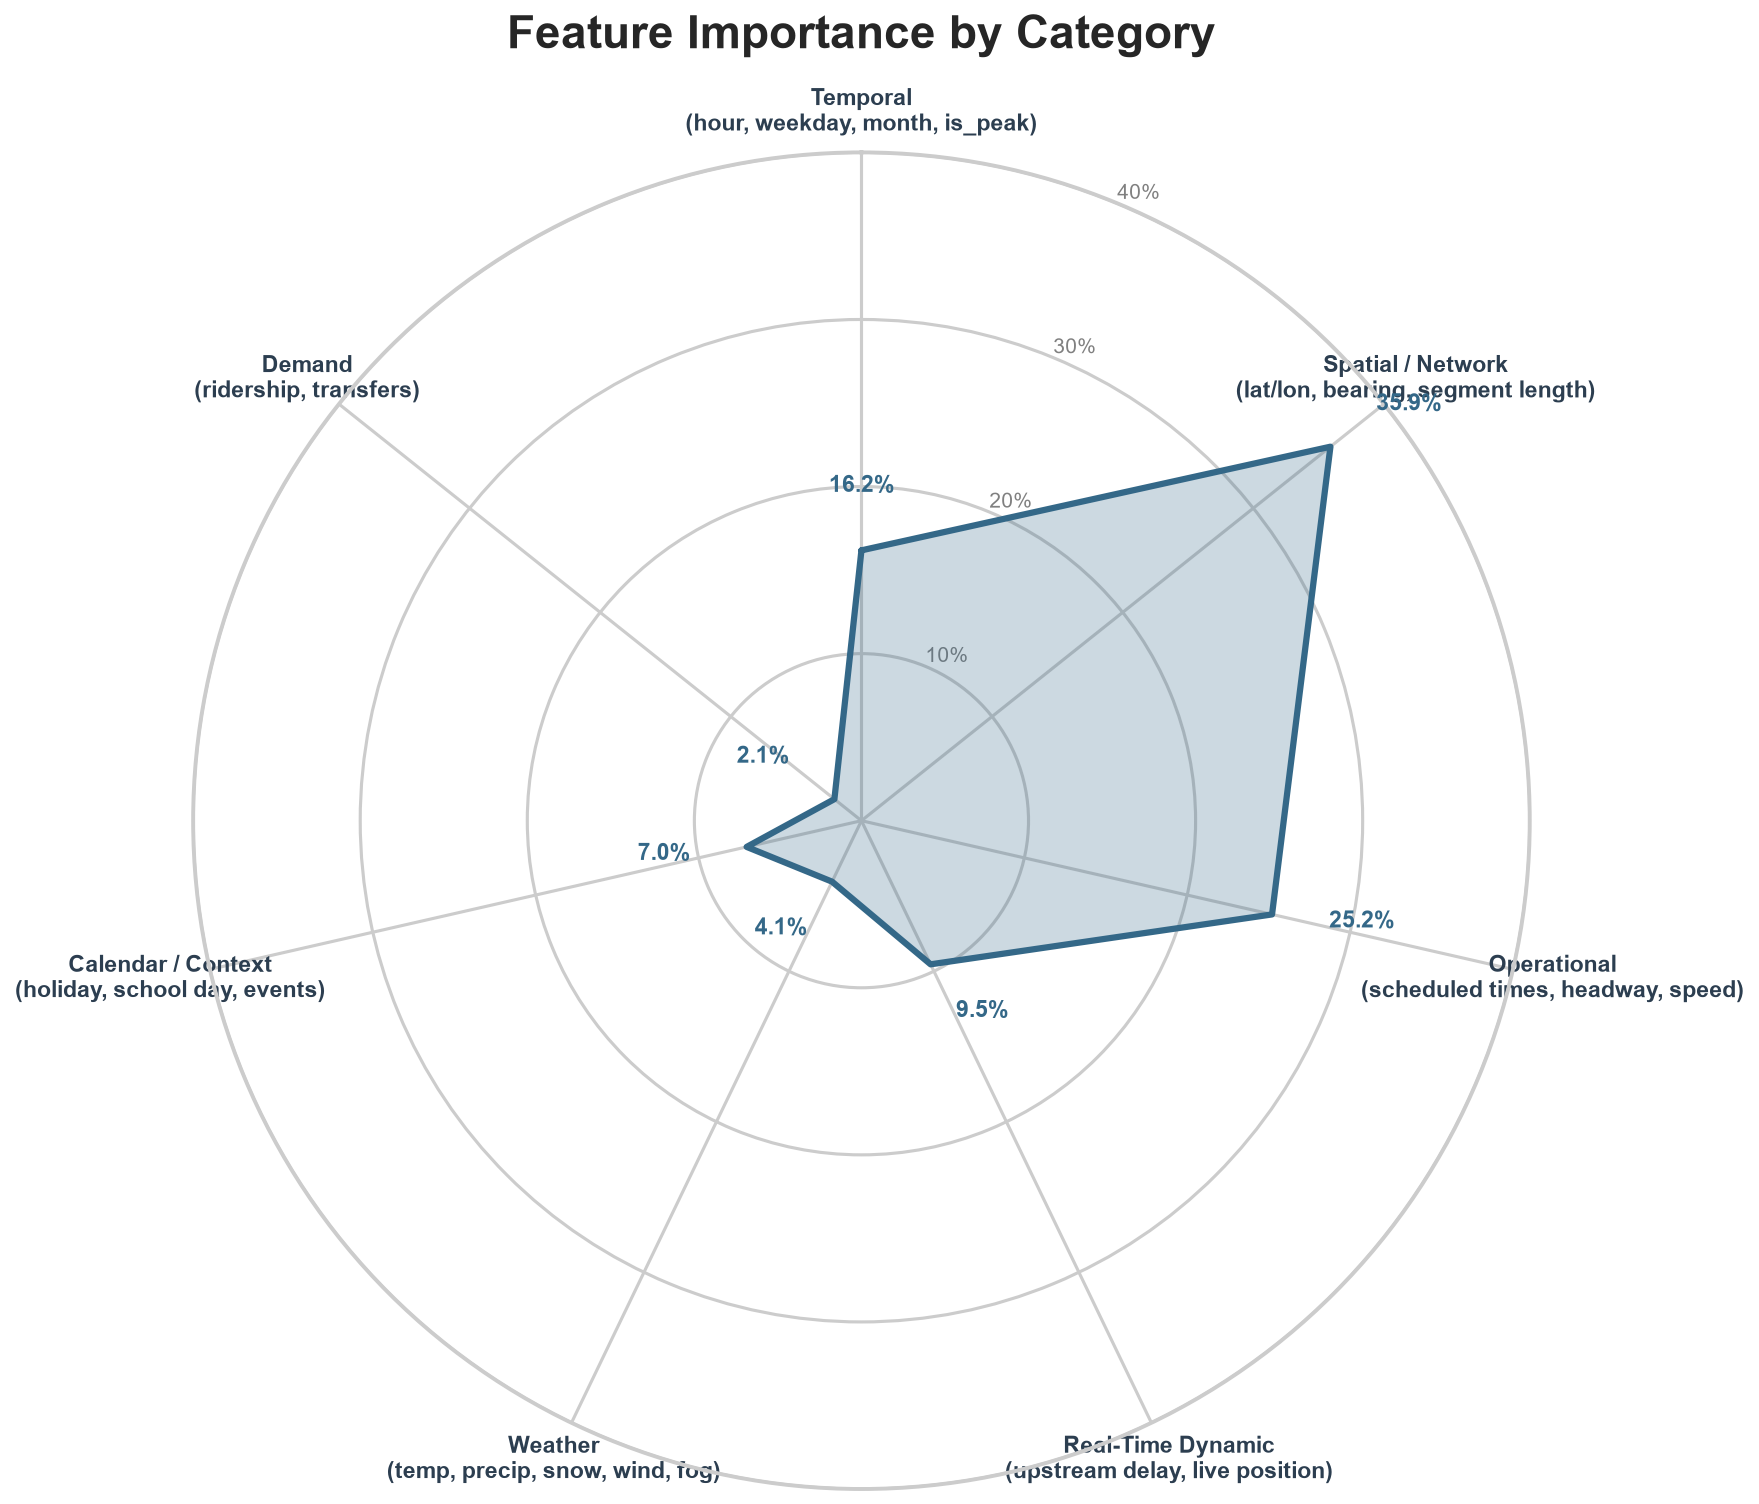

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set the style for presentation
sns.set_theme(style="whitegrid", context="talk")

# 1. Map features to categories based on the provided image
category_weights = {
    "Temporal": 0.0,
    "Spatial / Network": 0.0,
    "Operational": 0.0,
    "Real-Time Dynamic": 0.0,
    "Weather": 0.0,
    "Calendar / Context": 0.0,
    "Demand": 0.0
}

# Temporal 
category_weights["Temporal"] += 0.0297 + 0.1624 + 0.1211 + 0.0104

# Spatial / Network
category_weights["Spatial / Network"] += (
    0.0488 + 0.0460 + 0.0405 + 0.1856 + 
    0.3240 + 0.0424 + 0.0160 + 0.0147
)

# Operational
category_weights["Operational"] += (
    0.0933 + 0.0500 + 0.0461 + 0.0295 + 
    0.0208 + 0.0552 + 0.1108 + 0.0984
)

# Real-Time Dynamic
category_weights["Real-Time Dynamic"] += 0.0566 + 0.0587 + 0.0755

# Weather
category_weights["Weather"] += (
    0.0138 + 0.0093 + 0.0259 + 0.0096 + 
    0.0085 + 0.0061 + 0.0047 + 0.0031
)

# Calendar / Context
category_weights["Calendar / Context"] += 0.0097 + 0.0602 + 0.0523 + 0.0187

# Demand
category_weights["Demand"] += 0.0233 + 0.0181

# Normalize weights to sum to 100%
total_weight = sum(category_weights.values())
normalized_weights = [(w / total_weight) * 100 for w in category_weights.values()]

# 2. Define the multi-line labels including the features
labels = [
    "Temporal\n(hour, weekday, month, is_peak)",
    "Spatial / Network\n(lat/lon, bearing, segment length)",
    "Operational\n(scheduled times, headway, speed)",
    "Real-Time Dynamic\n(upstream delay, live position)",
    "Weather\n(temp, precip, snow, wind, fog)",
    "Calendar / Context\n(holiday, school day, events)",
    "Demand\n(ridership, transfers)"
]

def create_category_radar_chart_with_features(labels, weights):
    """Generates a radar chart for the feature categories with detailed labels."""
    num_vars = len(labels)
    
    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    
    # Complete the loop for plotting
    weights_plot = weights + weights[:1]
    angles_plot = angles + angles[:1]
    
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))
    
    # Chart styling colors matching the image UI
    line_color = "#346888" 
    fill_color = "#346888"
    
    # Plot outline and fill
    ax.plot(angles_plot, weights_plot, color=line_color, linewidth=3, linestyle='solid')
    ax.fill(angles_plot, weights_plot, color=fill_color, alpha=0.25)
    
    # Orient the chart so the first category is at the top
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # Add detailed category labels
    ax.set_xticks(angles)
    # Using a slightly smaller font size to accommodate the extra text gracefully
    ax.set_xticklabels(labels, fontsize=11, fontweight='bold', color="#2C3E50")
    
    # Format radial grids/ticks (10%, 20%, 30%, 40%)
    ax.set_yticks([10, 20, 30, 40])
    ax.set_yticklabels(["10%", "20%", "30%", "40%"], color="grey", size=10)
    ax.set_ylim(0, 40)
    
    # Display the actual percentage values near the data points
    for angle, weight in zip(angles, weights):
        # Adjust horizontal alignment based on quadrant to prevent overlapping with line
        ha = 'center'
        if 0 < angle < np.pi:
            ha = 'left'
        elif np.pi < angle < 2 * np.pi:
            ha = 'right'
            
        # Shift the text label outward slightly
        ax.text(angle, weight + 3.5, f"{weight:.1f}%", 
                color=line_color, fontweight='bold', size=11, 
                horizontalalignment=ha)
    
    ax.set_title("Feature Importance by Category", size=22, fontweight='bold', pad=50)
    
    # Adjust layout to prevent labels from being cropped
    plt.tight_layout()
    plt.show()

# Generate the chart
create_category_radar_chart_with_features(labels, normalized_weights)

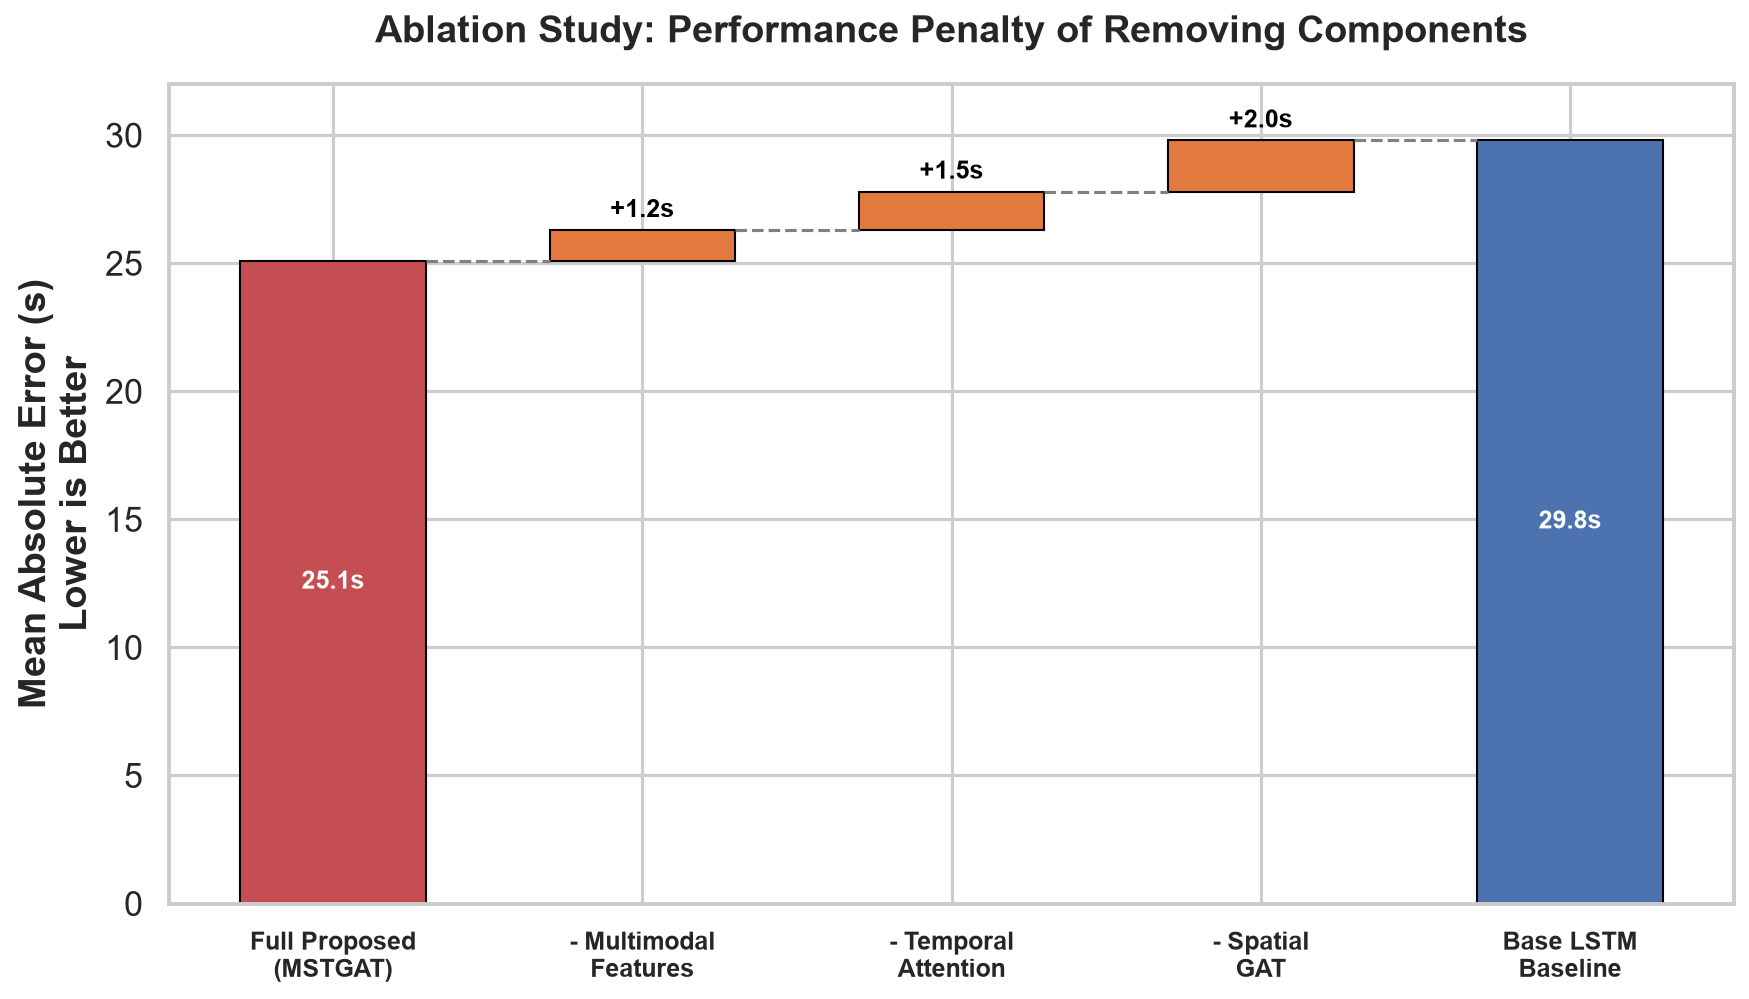

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set the style for presentation
sns.set_theme(style="whitegrid", context="talk")

# 1. Define Ablation Steps and Values (Dummy values for demonstration)
# We track the increase in error (MAE) as components are removed
labels = [
    'Full Proposed\n(MSTGAT)', 
    '- Multimodal\nFeatures', 
    '- Temporal\nAttention', 
    '- Spatial\nGAT', 
    'Base LSTM\nBaseline'
]

# Absolute MAE of the full model, the penalties (+MAE), and the final Baseline MAE
changes = [25.1, 1.2, 1.5, 2.0, 29.8]

# Calculate the starting heights (bottoms) for each bar
bottoms = [0, 25.1, 26.3, 27.8, 0]

# 2. Setup the Chart
fig, ax = plt.subplots(figsize=(12, 7))

# Colors: 
# Highlight color (Muted Red) for the full model
# Penalty color (Orange/Coral) for removals
# Base color (Muted Blue) for the final degraded baseline
colors = ['#C44E52', '#E27A3F', '#E27A3F', '#E27A3F', '#4C72B0']

x_pos = np.arange(len(labels))
width = 0.6

# 3. Plot the bars
bars = ax.bar(
    x_pos, 
    [changes[0], changes[1], changes[2], changes[3], changes[4]], 
    bottom=bottoms, 
    width=width, 
    color=colors, 
    edgecolor='black',
    linewidth=1
)

# 4. Add Step Connecting Lines
for i in range(len(labels) - 1):
    # The line connects the top right of the current bar to the top left of the next bar
    current_top = bottoms[i] + changes[i]
    if i == 0:
        current_top = changes[i]
        
    ax.plot(
        [x_pos[i] + width/2, x_pos[i+1] - width/2], 
        [current_top, current_top], 
        color='grey', 
        linestyle='--', 
        linewidth=1.5
    )

# 5. Add Text Labels on the Bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    bottom = bar.get_y()
    
    # Format the text (Totals get absolute values, steps get '+' signs)
    if i == 0 or i == len(labels) - 1:
        text = f"{height:.1f}s"
        y_text = bottom + height / 2  # Center text in total bars
    else:
        text = f"+{height:.1f}s"
        y_text = bottom + height + 0.3 # Place text slightly above step bars
        
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        y_text, 
        text, 
        ha='center', 
        va='bottom' if (i != 0 and i != len(labels)-1) else 'center', 
        fontweight='bold', 
        color='black' if (i != 0 and i != len(labels)-1) else 'white',
        fontsize=12
    )

# 6. Formatting and Labels
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontweight='bold', fontsize=12)
ax.set_ylabel("Mean Absolute Error (s)\nLower is Better", fontweight='bold')
ax.set_title("Ablation Study: Performance Penalty of Removing Components", fontweight='bold', pad=20)

# Set Y-axis limits slightly above the max value for headroom
ax.set_ylim(0, 32)

plt.tight_layout()
plt.show()

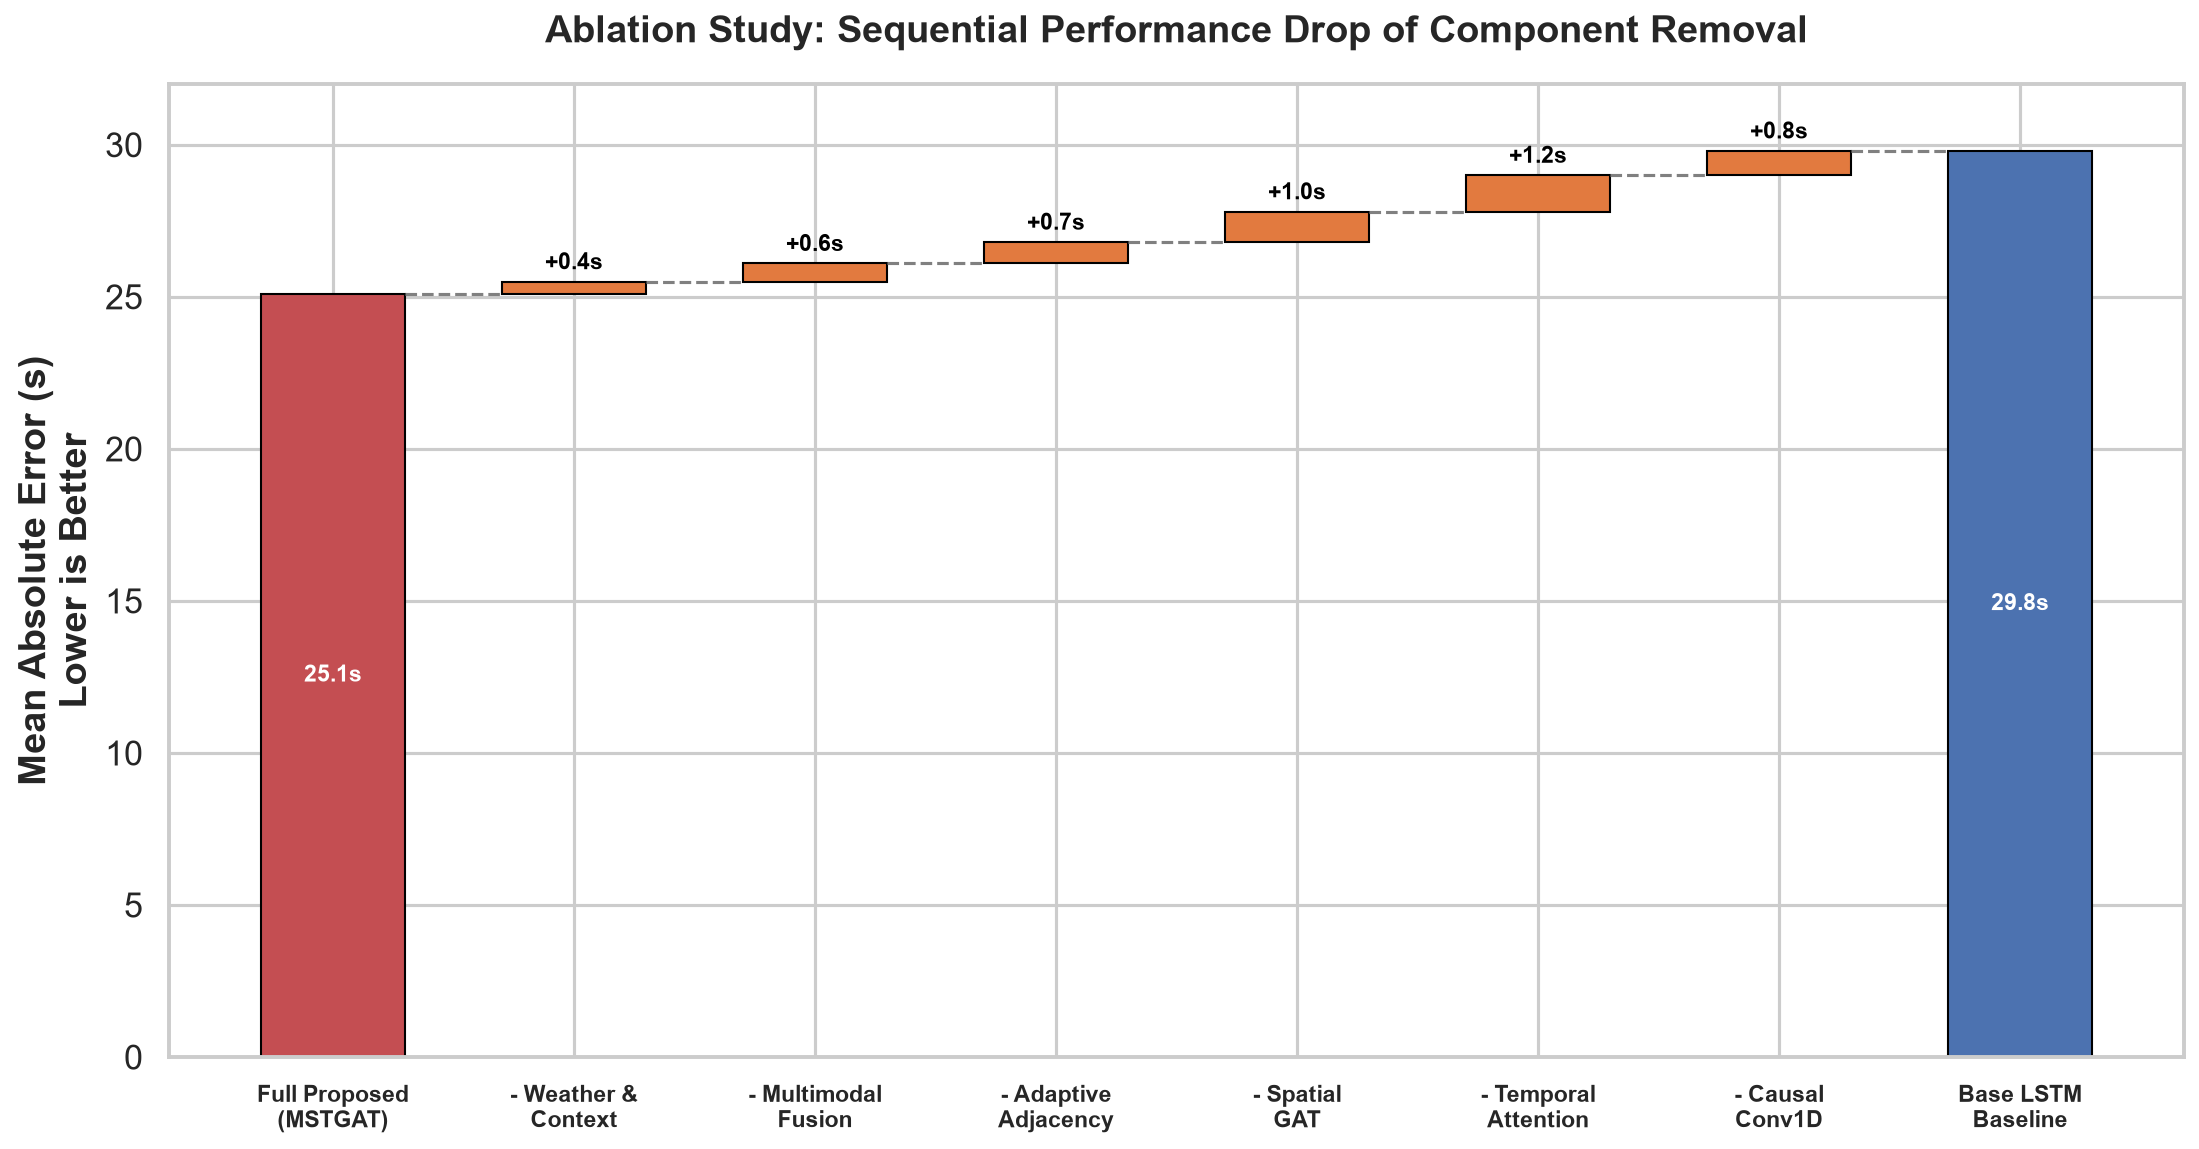

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set the style for presentation
sns.set_theme(style="whitegrid", context="talk")

# 1. Define Ablation Steps and Values (Expanded to 8 categories)
# We track the increase in error (MAE) as granular components are removed
labels = [
    'Full Proposed\n(MSTGAT)', 
    '- Weather &\nContext', 
    '- Multimodal\nFusion', 
    '- Adaptive\nAdjacency',
    '- Spatial\nGAT', 
    '- Temporal\nAttention', 
    '- Causal\nConv1D',
    'Base LSTM\nBaseline'
]

# Absolute MAE of the full model, the specific penalties (+MAE) for each removed component, 
# and the final absolute Baseline MAE.
# 25.1 + 0.4 + 0.6 + 0.7 + 1.0 + 1.2 + 0.8 = 29.8
changes = [25.1, 0.4, 0.6, 0.7, 1.0, 1.2, 0.8, 29.8]

# Calculate the starting heights (bottoms) for each bar to create the staircase effect
bottoms = [
    0,     # Full Proposed (Starts at 0)
    25.1,  # - Weather & Context
    25.5,  # - Multimodal Fusion
    26.1,  # - Adaptive Adjacency
    26.8,  # - Spatial GAT
    27.8,  # - Temporal Attention
    29.0,  # - Causal Conv1D
    0      # Base LSTM Baseline (Starts at 0)
]

# 2. Setup the Chart
fig, ax = plt.subplots(figsize=(15, 8)) # Made slightly wider to fit 8 labels comfortably

# Colors: 
# Highlight color (Muted Red) for the full model
# Penalty color (Orange/Coral) for removals
# Base color (Muted Blue) for the final degraded baseline
colors = ['#C44E52'] + ['#E27A3F'] * 6 + ['#4C72B0']

x_pos = np.arange(len(labels))
width = 0.6

# 3. Plot the bars
bars = ax.bar(
    x_pos, 
    changes, 
    bottom=bottoms, 
    width=width, 
    color=colors, 
    edgecolor='black',
    linewidth=1
)

# 4. Add Step Connecting Lines
for i in range(len(labels) - 1):
    # The line connects the top right of the current bar to the top left of the next bar
    current_top = bottoms[i] + changes[i]
    if i == 0:
        current_top = changes[i]
        
    ax.plot(
        [x_pos[i] + width/2, x_pos[i+1] - width/2], 
        [current_top, current_top], 
        color='grey', 
        linestyle='--', 
        linewidth=1.5
    )

# 5. Add Text Labels on the Bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    bottom = bar.get_y()
    
    # Format the text (Totals get absolute values, steps get '+' signs)
    if i == 0 or i == len(labels) - 1:
        text = f"{height:.1f}s"
        y_text = bottom + height / 2  # Center text in total bars
    else:
        text = f"+{height:.1f}s"
        y_text = bottom + height + 0.25 # Place text slightly above step bars
        
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        y_text, 
        text, 
        ha='center', 
        va='bottom' if (i != 0 and i != len(labels)-1) else 'center', 
        fontweight='bold', 
        color='black' if (i != 0 and i != len(labels)-1) else 'white',
        fontsize=11
    )

# 6. Formatting and Labels
ax.set_xticks(x_pos)
# slightly smaller font so 8 columns fit perfectly
ax.set_xticklabels(labels, fontweight='bold', fontsize=11) 
ax.set_ylabel("Mean Absolute Error (s)\nLower is Better", fontweight='bold')
ax.set_title("Ablation Study: Sequential Performance Drop of Component Removal", fontweight='bold', pad=20)

# Set Y-axis limits slightly above the max value for headroom
ax.set_ylim(0, 32)

plt.tight_layout()
plt.show()

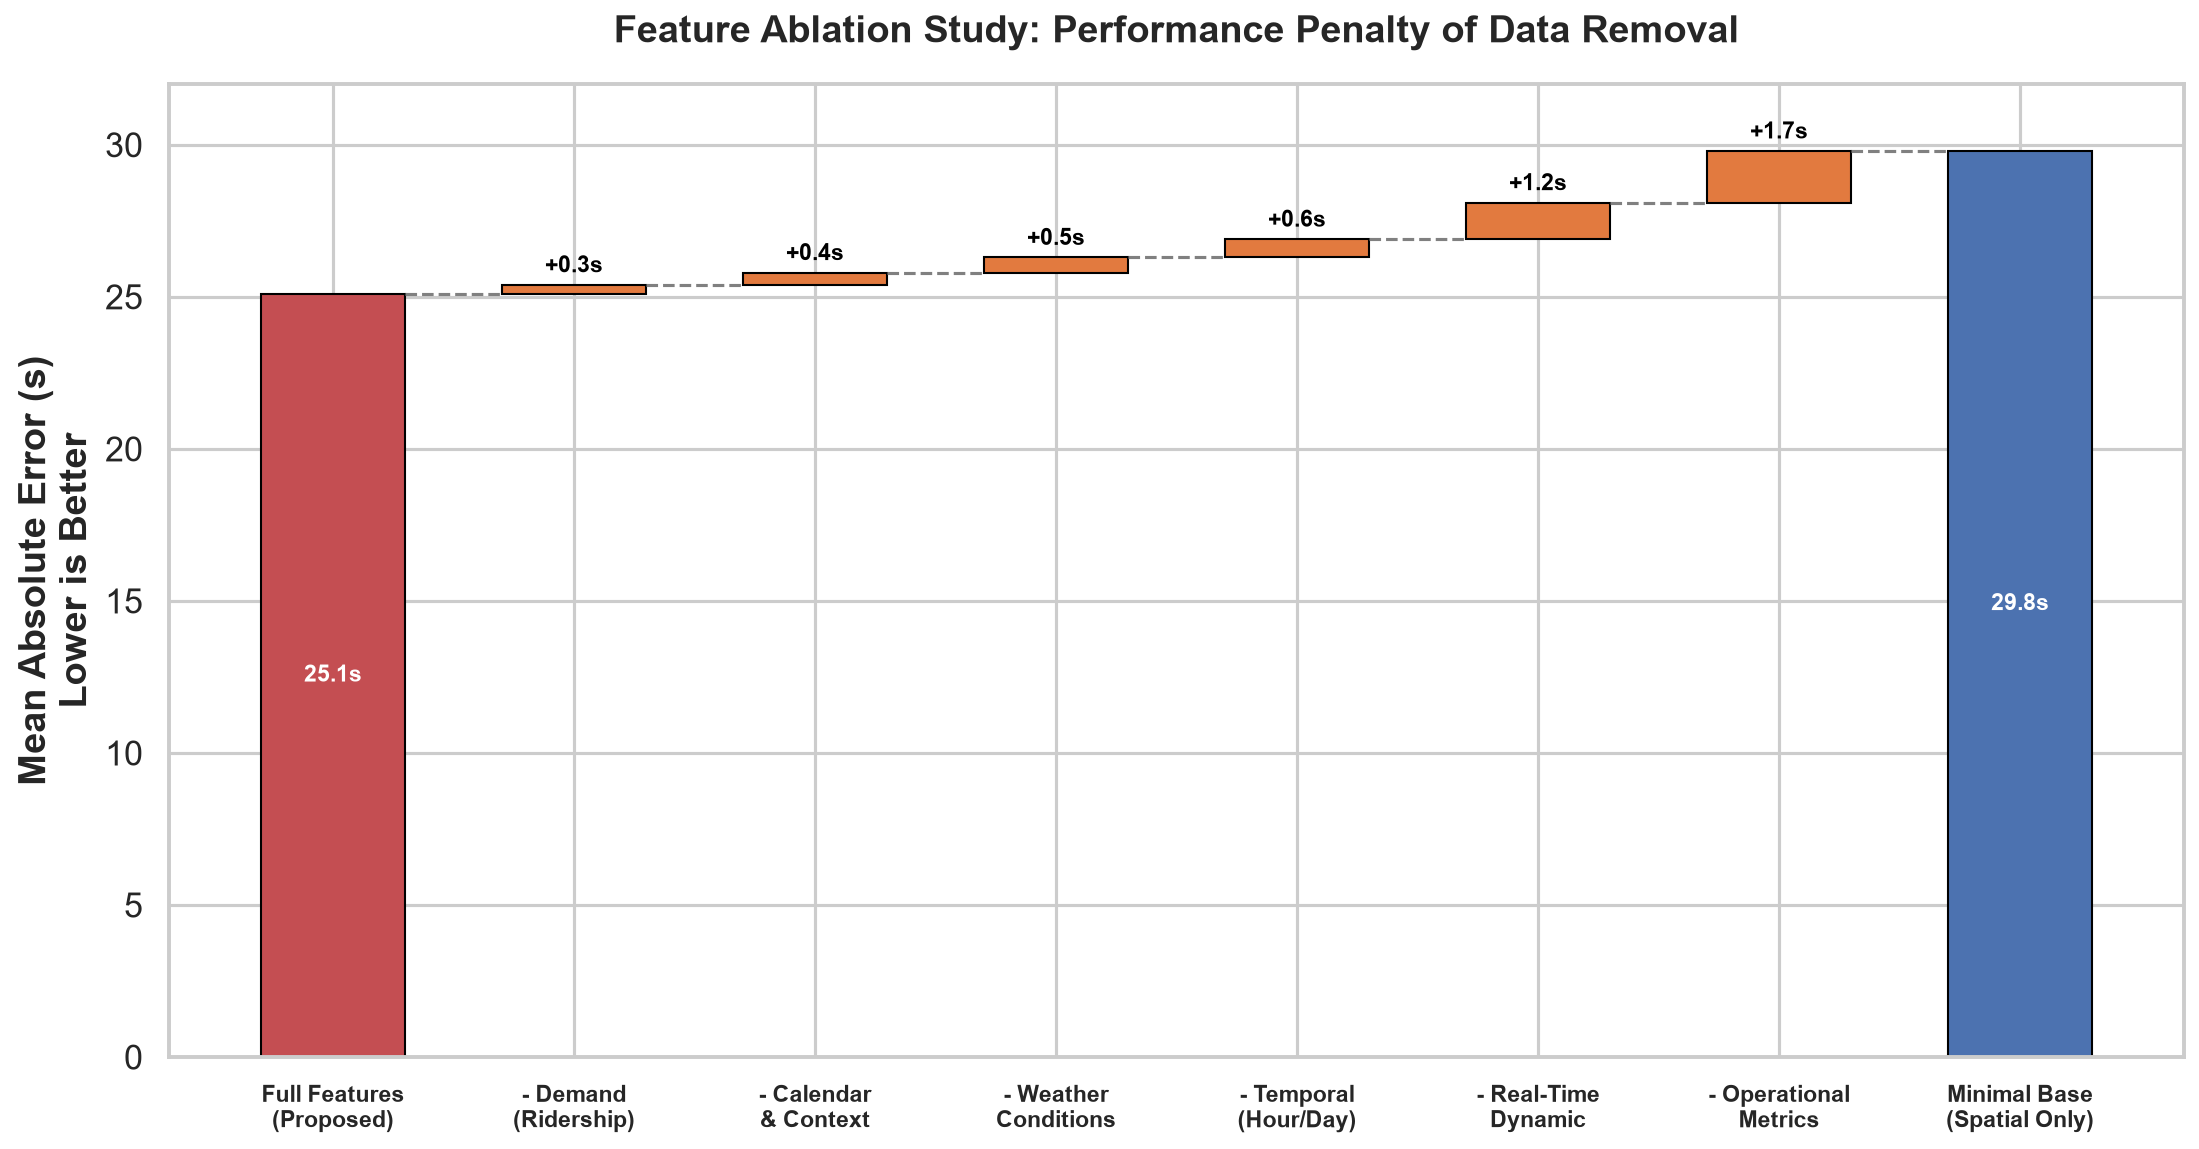

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set the style for presentation
sns.set_theme(style="whitegrid", context="talk")

# 1. Define Ablation Steps and Values (Focusing purely on features)
# We track the increase in error (MAE) as feature categories are removed
labels = [
    'Full Features\n(Proposed)', 
    '- Demand\n(Ridership)', 
    '- Calendar\n& Context', 
    '- Weather\nConditions',
    '- Temporal\n(Hour/Day)', 
    '- Real-Time\nDynamic', 
    '- Operational\nMetrics',
    'Minimal Base\n(Spatial Only)'
]

# Absolute MAE of the full model, the specific penalties (+MAE) for each removed feature group, 
# and the final absolute Minimal Base MAE.
# 25.1 + 0.3 + 0.4 + 0.5 + 0.6 + 1.2 + 1.7 = 29.8
changes = [25.1, 0.3, 0.4, 0.5, 0.6, 1.2, 1.7, 29.8]

# Calculate the starting heights (bottoms) for each bar to create the staircase effect
bottoms = [
    0,     # Full Features (Starts at 0)
    25.1,  # - Demand
    25.4,  # - Calendar & Context
    25.8,  # - Weather
    26.3,  # - Temporal
    26.9,  # - Real-Time Dynamic
    28.1,  # - Operational Metrics
    0      # Minimal Base (Starts at 0)
]

# 2. Setup the Chart
fig, ax = plt.subplots(figsize=(15, 8)) 

# Colors: 
# Highlight color (Muted Red) for the full model
# Penalty color (Orange/Coral) for removals
# Base color (Muted Blue) for the final degraded baseline
colors = ['#C44E52'] + ['#E27A3F'] * 6 + ['#4C72B0']

x_pos = np.arange(len(labels))
width = 0.6

# 3. Plot the bars
bars = ax.bar(
    x_pos, 
    changes, 
    bottom=bottoms, 
    width=width, 
    color=colors, 
    edgecolor='black',
    linewidth=1
)

# 4. Add Step Connecting Lines
for i in range(len(labels) - 1):
    # The line connects the top right of the current bar to the top left of the next bar
    current_top = bottoms[i] + changes[i]
    if i == 0:
        current_top = changes[i]
        
    ax.plot(
        [x_pos[i] + width/2, x_pos[i+1] - width/2], 
        [current_top, current_top], 
        color='grey', 
        linestyle='--', 
        linewidth=1.5
    )

# 5. Add Text Labels on the Bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    bottom = bar.get_y()
    
    # Format the text (Totals get absolute values, steps get '+' signs)
    if i == 0 or i == len(labels) - 1:
        text = f"{height:.1f}s"
        y_text = bottom + height / 2  # Center text in total bars
    else:
        text = f"+{height:.1f}s"
        y_text = bottom + height + 0.25 # Place text slightly above step bars
        
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        y_text, 
        text, 
        ha='center', 
        va='bottom' if (i != 0 and i != len(labels)-1) else 'center', 
        fontweight='bold', 
        color='black' if (i != 0 and i != len(labels)-1) else 'white',
        fontsize=11
    )

# 6. Formatting and Labels
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontweight='bold', fontsize=11) 
ax.set_ylabel("Mean Absolute Error (s)\nLower is Better", fontweight='bold')
ax.set_title("Feature Ablation Study: Performance Penalty of Data Removal", fontweight='bold', pad=20)

# Set Y-axis limits slightly above the max value for headroom
ax.set_ylim(0, 32)

plt.tight_layout()
plt.show()